# Elektrostatika

**Mata Kuliah:** Elektrodinamika Klasik (Program Magister Fisika, Universitas Padjadjaran)  
**Topik Pokok:** Gaya Listrik (Hukum Coulomb), Medan Listrik (Hukum Gauss), Potensial Listrik & Energi Potensial (Persamaan Laplace), Syarat Batas (Metode Keunikan dan Separasi Variabel), dan Kapasitansi Dielektrik.  

---

## 1. Pendahuluan: Kerangka Teori Elektrostatika

**Rujukan utama:** David J. Griffiths, *Introduction to Electrodynamics*, edisi ke-4, bab 2–4. Uraian berikut merupakan parafrasa dan sintesis konsep, bukan kutipan: bab 2 membahas medan, Hukum Gauss, potensial, energi, dan konduktor; bab 3 membahas persamaan Laplace, keunikan, dan separasi variabel; bab 4 membahas dielektrik, polarisasi, serta medan pergeseran listrik.

Elektrostatika mengkaji medan listrik yang tidak berubah terhadap waktu dan dihasilkan oleh muatan yang diam dalam kerangka acuan yang dipakai. Untuk sumber elektrostatik, rapat muatan tidak berubah terhadap waktu; arus konduksi tidak menjadi sumber dalam model ini:
$\frac{\partial \rho}{\partial t} = 0, \quad \mathbf{J} = \mathbf{0}$

Secara fundamental, interaksi elektrostatik di ruang hampa diatur oleh dua persamaan Maxwell elektrostatika:
1. **Hukum Gauss (Bentuk Diferensial):**
   $$\nabla \cdot \mathbf{E} = \frac{\rho}{\epsilon_0}$$
   Fluks medan listrik yang menembus sembarang permukaan tertutup sebanding dengan total muatan listrik yang dilingkupi oleh permukaan tersebut.
2. **Sifat Konservatif Medan Elektrostatik:**
   $$\nabla \times \mathbf{E} = \mathbf{0} \iff \oint_C \mathbf{E} \cdot d\mathbf{l} = 0$$
   Curl medan listrik statik selalu lenyap, yang mengimplikasikan bahwa medan elektrostatik dapat direpresentasikan secara eksak sebagai gradien dari suatu fungsi potensial skalar $V(\mathbf{r})$:
   $$\mathbf{E}(\mathbf{r}) = -\nabla V(\mathbf{r})$$

Substitusi hubungan potensial ke dalam Hukum Gauss menghasilkan **Persamaan Poisson**:
$$\nabla \cdot (-\nabla V) = \frac{\rho}{\epsilon_0} \implies \nabla^2 V = -\frac{\rho}{\epsilon_0}$$

Pada ruang yang bebas muatan lokal ($\rho = 0$), persamaan ini tereduksi menjadi **Persamaan Laplace**:
$\nabla^2 V = 0$
Persamaan Poisson berlaku di daerah bermuatan; persamaan Laplace adalah kasus khususnya di daerah tanpa muatan.

### 1.2 Prinsip Superposisi Linear: Fondasi Universal Elektrostatika
Karena operator divergensi $\nabla \cdot$, gradien $\nabla$, dan Laplacian $\nabla^2$ adalah operator diferensial linear, persamaan dasar elektrostatika mematuhi **Prinsip Superposisi Linear**:
$$\nabla \cdot (\mathbf{E}_1 + \mathbf{E}_2) = \nabla \cdot \mathbf{E}_1 + \nabla \cdot \mathbf{E}_2 = \frac{\rho_1 + \rho_2}{\epsilon_0}$$
$$\nabla^2 (V_1 + V_2) = \nabla^2 V_1 + \nabla^2 V_2 = -\frac{\rho_1 + \rho_2}{\epsilon_0}$$

Konsekuensinya, jika sebuah sistem terdiri dari distribusi muatan total $\rho(\mathbf{r}) = \sum_i \rho_i(\mathbf{r})$, maka medan listrik dan potensial total di setiap titik di ruang merupakan penjumlahan linear murni dari kontribusi masing-masing komponen sumber:
$$\mathbf{E}(\mathbf{r}) = \sum_{i=1}^N \mathbf{E}_i(\mathbf{r}), \quad V(\mathbf{r}) = \sum_{i=1}^N V_i(\mathbf{r})$$

Pada notebook komputasi ini, **lima pilar materi elektrostatika fundamental** dikupas secara tuntas:
1. **Gaya Listrik (Hukum Coulomb):** Interaksi muatan titik & kontinu serta superposisi gaya vektor.
2. **Medan Listrik (Hukum Gauss):** Fluks medan, simetri sferis, dan superposisi medan/fluks pada problem rongga (*cavity problem*).
3. **Potensial Listrik & Energi Potensial (Persamaan Laplace):** Integrasi garis medan, hubungan $\mathbf{E} = -\nabla V$, superposisi skalar potensial vs non-linearitas energi elektrostatik ($W_{12} = \epsilon_0 \int \mathbf{E}_1 \cdot \mathbf{E}_2 d\tau$).
4. **Syarat Batas (Metode Keunikan dan Separasi Variabel):** Diskontinuitas komponen normal medan di antarmuka, pembuktian Teorema Keunikan (Dirichlet/Neumann), penyelesaian analitik Persamaan Laplace via Metode Separasi Variabel koordinat Kartesian (deret Fourier ortogonal), dan superposisi solusi basis.
5. **Kapasitansi dan Bahan Dielektrik:** Polarisasi makroskopis $\mathbf{P}$, muatan terikat $\rho_b$ dan $\sigma_b$, medan pergeseran listrik $\mathbf{D} = \epsilon \mathbf{E}$, dan superposisi medan bebas/terikat serta kapasitor majemuk.


In [1]:
# Verifikasi pustaka komputasi
%config InlineBackend.figure_formats = ['svg']
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}
import sys
import numpy as np
import sympy as sp
import matplotlib

print(f"Python Environment     : Python {sys.version.split()[0]}")
print(f"NumPy (Komputasi Vektor): v{np.__version__}")
print(f"SymPy (Analisis Simbol) : v{sp.__version__}")
print(f"Matplotlib (Visualisasi): v{matplotlib.__version__}")


Python Environment     : Python 3.14.7
NumPy (Komputasi Vektor): v2.5.2
SymPy (Analisis Simbol) : v1.14.0
Matplotlib (Visualisasi): v3.11.1


In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import html as _html
import json as _json
from IPython.display import HTML, display
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform

# Konstanta Fundamental Fisika (SI)
EPSILON_0 = 8.8541878128e-12
K_E = 1.0 / (4.0 * np.pi * EPSILON_0)

# Konfigurasi plot analitik 2D & 3D Matplotlib
# Konfigurasi plot analitik 2D & 3D Matplotlib (Tema Resmi Matplotlib Toolkits - Light Theme)
plt.rcParams.update({
    'figure.figsize': (8.5, 8.5),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#111111',
    'xtick.color': '#111111',
    'ytick.color': '#111111',
    'text.color': '#111111',
    'grid.color': '#b0b0b0',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'font.size': 10
})

class Arrow3D(FancyArrowPatch):
    """Renderer Panah 3D Presisi Tinggi untuk Sistem Koordinat dan Medan Vektor."""
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        return np.min(zs)


def draw_triad_3d(ax, pos, u1, u2, u3, c1='#dc2626', c2='#16a34a', c3='#2563eb', length=0.4, lw=2.0, labels=None):
    pos = np.asarray(pos, dtype=float)
    u1 = np.asarray(u1, dtype=float) / np.linalg.norm(u1) * length
    u2 = np.asarray(u2, dtype=float) / np.linalg.norm(u2) * length
    u3 = np.asarray(u3, dtype=float) / np.linalg.norm(u3) * length
    
    ax.add_artist(Arrow3D([pos[0], pos[0]+u1[0]], [pos[1], pos[1]+u1[1]], [pos[2], pos[2]+u1[2]],
                          mutation_scale=10, color=c1, arrowstyle='-|>', lw=lw))
    ax.add_artist(Arrow3D([pos[0], pos[0]+u2[0]], [pos[1], pos[1]+u2[1]], [pos[2], pos[2]+u2[2]],
                          mutation_scale=10, color=c2, arrowstyle='-|>', lw=lw))
    ax.add_artist(Arrow3D([pos[0], pos[0]+u3[0]], [pos[1], pos[1]+u3[1]], [pos[2], pos[2]+u3[2]],
                          mutation_scale=10, color=c3, arrowstyle='-|>', lw=lw))
    if labels:
        ax.text(pos[0]+u1[0]*1.15, pos[1]+u1[1]*1.15, pos[2]+u1[2]*1.15, labels[0], color=c1, fontweight='bold', fontsize=9)
        ax.text(pos[0]+u2[0]*1.15, pos[1]+u2[1]*1.15, pos[2]+u2[2]*1.15, labels[1], color=c2, fontweight='bold', fontsize=9)
        ax.text(pos[0]+u3[0]*1.15, pos[1]+u3[1]*1.15, pos[2]+u3[2]*1.15, labels[2], color=c3, fontweight='bold', fontsize=9)


print(f"Konstanta Coulomb k_e = {K_E:.6e} N.m^2/C^2 | epsilon_0 = {EPSILON_0:.6e} F/m")


def setup_3d_pane(ax, xlim=(-0.5, 2.5), ylim=(-0.5, 2.5), zlim=(-0.5, 2.5), axis_len=2.5):
    """Mengatur gaya kanvas 3D transparan, grid halus, dan sumbu berwarna (merah-hijau-biru)."""
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#d1d5db')
    ax.yaxis.pane.set_edgecolor('#d1d5db')
    ax.zaxis.pane.set_edgecolor('#d1d5db')
    
    # Sumbu utama berwarna: x (merah), y (hijau), z (biru)
    ax.plot([0, axis_len], [0, 0], [0, 0], color='#dc2626', lw=1.8)
    ax.plot([0, 0], [0, axis_len], [0, 0], color='#16a34a', lw=1.8)
    ax.plot([0, 0], [0, 0], [0, axis_len], color='#2563eb', lw=2.0)
    ax.text(axis_len + 0.1, 0, 0, '$x$', color='#dc2626', fontsize=11, fontweight='bold')
    ax.text(0, axis_len + 0.1, 0, '$y$', color='#16a34a', fontsize=11, fontweight='bold')
    ax.text(0, 0, axis_len + 0.1, '$z$', color='#2563eb', fontsize=11, fontweight='bold')
    
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(*zlim)
    ax.set_xlabel('$x$ (m)', color='#111111')
    ax.set_ylabel('$y$ (m)', color='#111111')
    ax.set_zlabel('$z$ (m)', color='#111111')

print("Engine visualisasi 2D & 3D (Matplotlib) siap dengan konfigurasi tema dan triad vektor.")


Konstanta Coulomb k_e = 8.987552e+09 N.m^2/C^2 | epsilon_0 = 8.854188e-12 F/m
Engine visualisasi 2D & 3D (Matplotlib) siap dengan konfigurasi tema dan triad vektor.


---
## 1.1 Proyeksi Sistem Koordinat Fisis: Kartesis, Silinder, dan Bola

### Divergensi dan Curl dalam Koordinat Ortogonal
Untuk koordinat ortogonal $(q_1,q_2,q_3)$ dengan faktor skala $(h_1,h_2,h_3)$ dan $\mathbf{A}=A_1\hat{e}_1+A_2\hat{e}_2+A_3\hat{e}_3$:
$$\nabla\cdot\mathbf{A}=\frac{1}{h_1h_2h_3}\left[\frac{\partial(h_2h_3A_1)}{\partial q_1}+\frac{\partial(h_3h_1A_2)}{\partial q_2}+\frac{\partial(h_1h_2A_3)}{\partial q_3}\right]$$
Di silinder, $\nabla\cdot\mathbf{A}=\frac{1}{s}\frac{\partial(sA_s)}{\partial s}+\frac{1}{s}\frac{\partial A_\phi}{\partial\phi}+\frac{\partial A_z}{\partial z}$; di bola, $\nabla\cdot\mathbf{A}=\frac{1}{r^2}\frac{\partial(r^2A_r)}{\partial r}+\frac{1}{r\sin\theta}\frac{\partial(A_\theta\sin\theta)}{\partial\theta}+\frac{1}{r\sin\theta}\frac{\partial A_\phi}{\partial\phi}$.
Curl pada koordinat ortogonal dapat dihitung dengan $\nabla\times\mathbf{A}=\frac{1}{h_1h_2h_3}\begin{vmatrix}h_1\hat{e}_1&h_2\hat{e}_2&h_3\hat{e}_3\\\partial/\partial q_1&\partial/\partial q_2&\partial/\partial q_3\\h_1A_1&h_2A_2&h_3A_3\end{vmatrix}$. Faktor skala harus disertakan; rumus komponen Kartesian tidak dapat langsung dipakai untuk komponen silinder atau bola.
Divergensi mengukur sumber bersih medan per satuan volume, sedangkan curl mengukur sirkulasi lokal. Teorema Divergensi dan Teorema Stokes menghubungkan besaran lokal tersebut dengan besaran integral: $\int_{\mathcal V}\nabla\cdot\mathbf A\,d\tau=\oint_{\partial\mathcal V}\mathbf A\cdot d\mathbf a$ dan $\int_{\mathcal S}(\nabla\times\mathbf A)\cdot d\mathbf a=\oint_{\partial\mathcal S}\mathbf A\cdot d\mathbf l$.

> **Landasan Matematis & Metrik (Griffiths Bab 1 & Catatan Kuliah):**
> Dalam elektrodinamika klasik, pemilihan sistem koordinat ditentukan oleh simetri fisis masalah. Setiap sistem kurvilinear ortogonal didefinisikan oleh metrik faktor skala $h_i$, elemen diferensial lintasan $d\mathbf{l} = \sum h_i dq_i \hat{e}_i$, elemen volume $d\tau = h_1 h_2 h_3 dq_1 dq_2 dq_3$, serta triad vektor satuan lokal $\{\hat{e}_1, \hat{e}_2, \hat{e}_3\}$:
>
> 1. **Kartesis $(x, y, z)$:** $h_x = 1, h_y = 1, h_z = 1$, basis $\{\hat{i}, \hat{j}, \hat{k}\}$, besar vektor $|\mathbf{A}| = \sqrt{A_x^2 + A_y^2 + A_z^2}$.
> 2. **Silinder $(s, \phi, z)$:** $h_s = 1, h_\phi = s, h_z = 1$, basis $\{\hat{s}, \hat{\phi}, \hat{z}\}$, besar vektor $|\mathbf{A}| = \sqrt{A_s^2 + A_\phi^2 + A_z^2}$.
> 3. **Bola $(r, \theta, \phi)$:** $h_r = 1, h_\theta = r, h_\phi = r\sin\theta$, basis $\{\hat{r}, \hat{\theta}, \hat{\phi}\}$, besar vektor $|\mathbf{A}| = \sqrt{A_r^2 + A_\theta^2 + A_\phi^2}$.


In [3]:
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

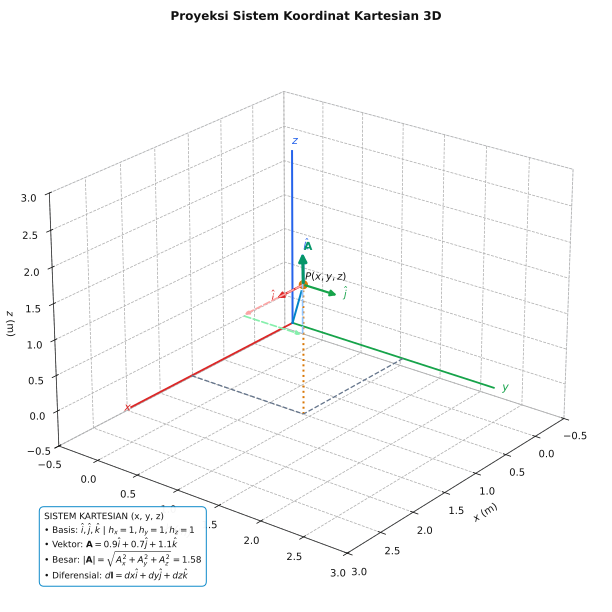

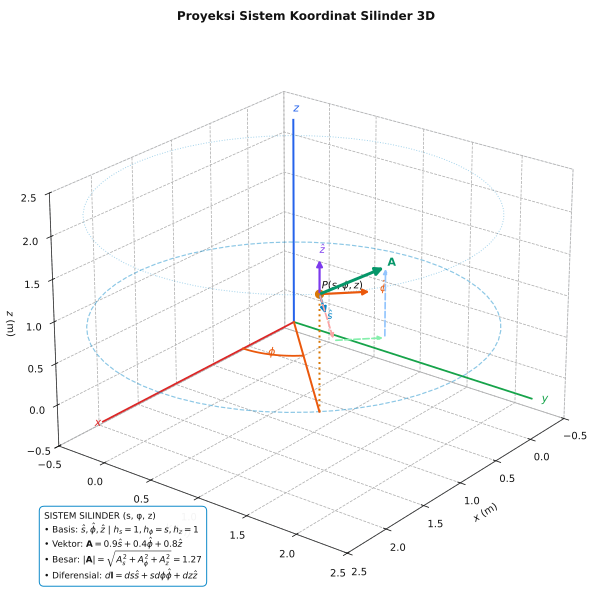

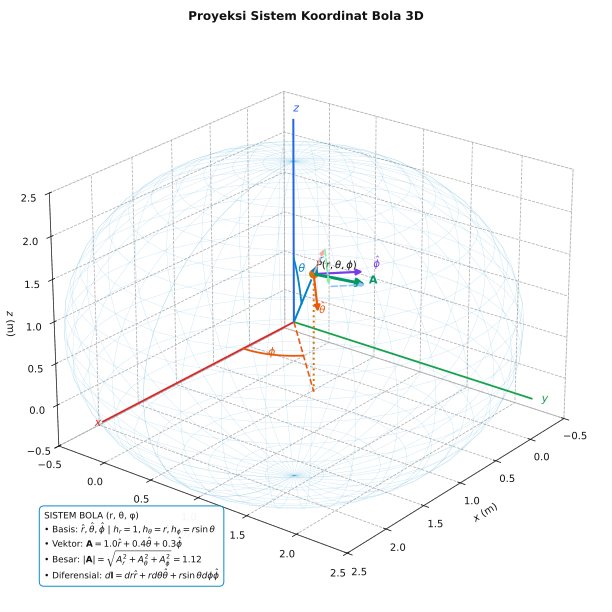

In [4]:
# Visualisasi 3D Proyeksi Sistem Koordinat Fisis: Kartesis, Silinder, dan Bola
# Ditampilkan sebagai 3 gambar terpisah dengan gaya proyeksi 3D presisi tinggi

def draw_vector_components_3d(ax, origin, components):
    """Gambar komponen vektor secara head-to-tail di belakang vektor resultan."""
    start = np.asarray(origin, dtype=float)
    component_colors = ['#fca5a5', '#86efac', '#93c5fd']
    for component, color in zip(components, component_colors):
        end = start + np.asarray(component, dtype=float)
        ax.add_artist(Arrow3D([start[0], end[0]], [start[1], end[1]], [start[2], end[2]],
                              mutation_scale=9, color=color, arrowstyle='-|>', lw=1.7, linestyle='--'))
        start = end


def plot_cartesian_projection_3d(x0=1.6, y0=1.4, z0=1.8):
    """Visualisasi Proyeksi 3D Sistem Koordinat Kartesian (x, y, z)."""
    fig = plt.figure(dpi=120)
    ax = fig.add_subplot(111, projection='3d')
    setup_3d_pane(ax, xlim=(-0.5, 3.0), ylim=(-0.5, 3.0), zlim=(-0.5, 3.0), axis_len=2.5)

    # Titik P
    ax.scatter([x0], [y0], [z0], color='#d97706', s=110, zorder=10, edgecolors='white', lw=1.2)
    ax.text(x0+0.1, y0+0.1, z0+0.15, r'$P(x,y,z)$', color='#111111', fontweight='bold', fontsize=10)

    # Proyeksi Kartesis
    ax.plot([x0, x0], [y0, y0], [0, z0], color='#d97706', ls=':', lw=2.0)
    ax.plot([0, x0], [y0, y0], [0, 0], color='#64748b', ls='--', lw=1.3)
    ax.plot([x0, x0], [0, y0], [0, 0], color='#64748b', ls='--', lw=1.3)
    ax.plot([0, x0], [0, y0], [0, z0], color='#0284c7', ls='-', lw=2.0)

    # Triad Vektor Satuan di P
    u_len = 0.42
    ax.add_artist(Arrow3D([x0, x0+u_len], [y0, y0], [z0, z0], mutation_scale=12, color='#dc2626', arrowstyle='-|>', lw=2.2))
    ax.text(x0+u_len+0.06, y0, z0, r'$\hat{i}$', color='#dc2626', fontweight='bold', fontsize=10)
    ax.add_artist(Arrow3D([x0, x0], [y0, y0+u_len], [z0, z0], mutation_scale=12, color='#16a34a', arrowstyle='-|>', lw=2.2))
    ax.text(x0, y0+u_len+0.06, z0, r'$\hat{j}$', color='#16a34a', fontweight='bold', fontsize=10)
    ax.add_artist(Arrow3D([x0, x0], [y0, y0], [z0, z0+u_len], mutation_scale=12, color='#2563eb', arrowstyle='-|>', lw=2.2))
    ax.text(x0, y0, z0+u_len+0.06, r'$\hat{k}$', color='#2563eb', fontweight='bold', fontsize=10)

    # Vektor Uji A
    Ax, Ay, Az = 0.9, 0.7, 1.1
    Amag = np.sqrt(Ax**2 + Ay**2 + Az**2)
    draw_vector_components_3d(ax, (x0, y0, z0), [(Ax, 0, 0), (0, Ay, 0), (0, 0, Az)])
    ax.add_artist(Arrow3D([x0, x0+Ax], [y0, y0+Ay], [z0, z0+Az], mutation_scale=16, color='#059669', arrowstyle='-|>', lw=3.0))
    ax.text(x0+Ax+0.07, y0+Ay+0.07, z0+Az+0.07, r'$\mathbf{A}$', color='#059669', fontweight='bold', fontsize=11)

    card1 = (
        "SISTEM KARTESIAN (x, y, z)\n"
        r"• Basis: $\hat{i}, \hat{j}, \hat{k}$ | $h_x=1, h_y=1, h_z=1$" + "\n"
        f"• Vektor: $\\mathbf{{A}} = {Ax:.1f}\\hat{{i}} + {Ay:.1f}\\hat{{j}} + {Az:.1f}\\hat{{k}}$\n"
        f"• Besar: $|\\mathbf{{A}}| = \\sqrt{{A_x^2+A_y^2+A_z^2}} = {Amag:.2f}$\n"
        r"• Diferensial: $d\mathbf{l}=dx\hat{i}+dy\hat{j}+dz\hat{k}$"
    )
    ax.text2D(0.04, 0.04, card1, transform=ax.transAxes, fontsize=8.8,
              bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#0284c7', alpha=0.95),
              color='#111111')
    ax.set_title('Proyeksi Sistem Koordinat Kartesian 3D', color='#111111', fontsize=12, pad=12, fontweight='bold')
    ax.view_init(elev=24, azim=38)
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_cylindrical_projection_3d(s0=1.8, phi0=np.pi/4, z0_cyl=1.4):
    """Visualisasi Proyeksi 3D Sistem Koordinat Silinder (s, phi, z)."""
    fig = plt.figure(dpi=120)
    ax = fig.add_subplot(111, projection='3d')
    setup_3d_pane(ax, xlim=(-0.5, 2.5), ylim=(-0.5, 2.5), zlim=(-0.5, 2.5), axis_len=2.5)

    xc = s0 * np.cos(phi0)
    yc = s0 * np.sin(phi0)
    zc = z0_cyl
    phi_c = np.linspace(0, 2*np.pi, 60)
    ax.plot(s0*np.cos(phi_c), s0*np.sin(phi_c), 0, color='#0284c7', lw=1.2, ls='--', alpha=0.45)
    ax.plot(s0*np.cos(phi_c), s0*np.sin(phi_c), zc, color='#0284c7', lw=1.0, ls=':', alpha=0.35)

    ax.scatter([xc], [yc], [zc], color='#d97706', s=110, zorder=10, edgecolors='white', lw=1.2)
    ax.text(xc+0.1, yc+0.1, zc+0.15, r'$P(s,\phi,z)$', color='#111111', fontweight='bold', fontsize=10)

    ax.plot([xc, xc], [yc, yc], [0, zc], color='#d97706', ls=':', lw=2.0)
    ax.plot([0, xc], [0, yc], [0, 0], color='#ea580c', ls='-', lw=2.0)
    arc_phi = np.linspace(0, phi0, 25)
    ax.plot(0.7*np.cos(arc_phi), 0.7*np.sin(arc_phi), 0, color='#ea580c', lw=1.8)
    ax.text(0.8*np.cos(phi0/2), 0.8*np.sin(phi0/2), 0.05, r'$\phi$', color='#ea580c', fontweight='bold', fontsize=11)

    # Triad Silinder di P
    u_len = 0.42
    ax.add_artist(Arrow3D([xc, xc+u_len*np.cos(phi0)], [yc, yc+u_len*np.sin(phi0)], [zc, zc],
                          mutation_scale=12, color='#0284c7', arrowstyle='-|>', lw=2.2))
    ax.text(xc+u_len*np.cos(phi0)+0.05, yc+u_len*np.sin(phi0)+0.05, zc, r'$\hat{s}$', color='#0284c7', fontweight='bold', fontsize=10)
    ax.add_artist(Arrow3D([xc, xc-u_len*np.sin(phi0)], [yc, yc+u_len*np.cos(phi0)], [zc, zc],
                          mutation_scale=12, color='#ea580c', arrowstyle='-|>', lw=2.2))
    ax.text(xc-u_len*np.sin(phi0)-0.05, yc+u_len*np.cos(phi0)+0.05, zc, r'$\hat{\phi}$', color='#ea580c', fontweight='bold', fontsize=10)
    ax.add_artist(Arrow3D([xc, xc], [yc, yc], [zc, zc+u_len], mutation_scale=12, color='#7c3aed', arrowstyle='-|>', lw=2.2))
    ax.text(xc, yc, zc+u_len+0.06, r'$\hat{z}$', color='#7c3aed', fontweight='bold', fontsize=10)

    # Vektor Uji A
    As, Aphi, Az = 0.9, 0.4, 0.8
    Amag_cyl = np.sqrt(As**2 + Aphi**2 + Az**2)
    Ax_c = As*np.cos(phi0) - Aphi*np.sin(phi0)
    Ay_c = As*np.sin(phi0) + Aphi*np.cos(phi0)
    draw_vector_components_3d(ax, (xc, yc, zc), [
        (As*np.cos(phi0), As*np.sin(phi0), 0),
        (-Aphi*np.sin(phi0), Aphi*np.cos(phi0), 0),
        (0, 0, Az),
    ])
    ax.add_artist(Arrow3D([xc, xc+Ax_c], [yc, yc+Ay_c], [zc, zc+Az], mutation_scale=16, color='#059669', arrowstyle='-|>', lw=3.0))
    ax.text(xc+Ax_c+0.07, yc+Ay_c+0.07, zc+Az+0.07, r'$\mathbf{A}$', color='#059669', fontweight='bold', fontsize=11)

    card2 = (
        "SISTEM SILINDER (s, φ, z)\n"
        r"• Basis: $\hat{s}, \hat{\phi}, \hat{z}$ | $h_s=1, h_\phi=s, h_z=1$" + "\n"
        f"• Vektor: $\\mathbf{{A}} = {As:.1f}\\hat{{s}} + {Aphi:.1f}\\hat{{\\phi}} + {Az:.1f}\\hat{{z}}$\n"
        f"• Besar: $|\\mathbf{{A}}| = \\sqrt{{A_s^2+A_\\phi^2+A_z^2}} = {Amag_cyl:.2f}$\n"
        r"• Diferensial: $d\mathbf{l}=ds\hat{s}+sd\phi\hat{\phi}+dz\hat{z}$"
    )
    ax.text2D(0.04, 0.04, card2, transform=ax.transAxes, fontsize=8.8,
              bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#0284c7', alpha=0.95),
              color='#111111')
    ax.set_title('Proyeksi Sistem Koordinat Silinder 3D', color='#111111', fontsize=12, pad=12, fontweight='bold')
    ax.view_init(elev=24, azim=38)
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_spherical_projection_3d(r0=2.0, th0=np.pi/4, phi0_sph=np.pi/4):
    """Visualisasi Proyeksi 3D Sistem Koordinat Bola (r, theta, phi)."""
    fig = plt.figure(dpi=120)
    ax = fig.add_subplot(111, projection='3d')
    setup_3d_pane(ax, xlim=(-0.5, 2.5), ylim=(-0.5, 2.5), zlim=(-0.5, 2.5), axis_len=2.5)

    xs = r0 * np.sin(th0) * np.cos(phi0_sph)
    ys = r0 * np.sin(th0) * np.sin(phi0_sph)
    zs = r0 * np.cos(th0)

    th_grid = np.linspace(0, np.pi, 25)
    phi_grid = np.linspace(0, 2*np.pi, 35)
    TH, PH = np.meshgrid(th_grid, phi_grid)
    XS = r0 * np.sin(TH) * np.cos(PH)
    YS = r0 * np.sin(TH) * np.sin(PH)
    ZS = r0 * np.cos(TH)
    ax.plot_wireframe(XS, YS, ZS, color='#0284c7', lw=0.4, alpha=0.22)

    ax.scatter([xs], [ys], [zs], color='#d97706', s=110, zorder=10, edgecolors='white', lw=1.2)
    ax.text(xs+0.1, ys+0.1, zs+0.15, r'$P(r,\theta,\phi)$', color='#111111', fontweight='bold', fontsize=10)

    ax.plot([0, xs], [0, ys], [0, zs], color='#0284c7', ls='-', lw=2.0)
    ax.plot([xs, xs], [ys, ys], [0, zs], color='#d97706', ls=':', lw=2.0)
    ax.plot([0, xs], [0, ys], [0, 0], color='#ea580c', ls='--', lw=1.6)

    arc_th = np.linspace(0, th0, 20)
    ax.plot(0.8*np.sin(arc_th)*np.cos(phi0_sph), 0.8*np.sin(arc_th)*np.sin(phi0_sph), 0.8*np.cos(arc_th), color='#0284c7', lw=1.8)
    ax.text(0.9*np.sin(th0/2)*np.cos(phi0_sph), 0.9*np.sin(th0/2)*np.sin(phi0_sph), 0.9*np.cos(th0/2), r'$\theta$', color='#0284c7', fontweight='bold', fontsize=11)

    arc_phi_s = np.linspace(0, phi0_sph, 20)
    ax.plot(0.7*np.cos(arc_phi_s), 0.7*np.sin(arc_phi_s), 0, color='#ea580c', lw=1.8)
    ax.text(0.8*np.cos(phi0_sph/2), 0.8*np.sin(phi0_sph/2), 0.05, r'$\phi$', color='#ea580c', fontweight='bold', fontsize=11)

    # Triad Bola di P
    u_len = 0.42
    rx = np.sin(th0)*np.cos(phi0_sph); ry = np.sin(th0)*np.sin(phi0_sph); rz = np.cos(th0)
    ax.add_artist(Arrow3D([xs, xs+u_len*rx], [ys, ys+u_len*ry], [zs, zs+u_len*rz],
                          mutation_scale=12, color='#0284c7', arrowstyle='-|>', lw=2.2))
    ax.text(xs+u_len*rx+0.05, ys+u_len*ry+0.05, zs+u_len*rz+0.05, r'$\hat{r}$', color='#0284c7', fontweight='bold', fontsize=10)
    tx = np.cos(th0)*np.cos(phi0_sph); ty = np.cos(th0)*np.sin(phi0_sph); tz = -np.sin(th0)
    ax.add_artist(Arrow3D([xs, xs+u_len*tx], [ys, ys+u_len*ty], [zs, zs+u_len*tz],
                          mutation_scale=12, color='#ea580c', arrowstyle='-|>', lw=2.2))
    ax.text(xs+u_len*tx+0.05, ys+u_len*ty+0.05, zs+u_len*tz+0.05, r'$\hat{\theta}$', color='#ea580c', fontweight='bold', fontsize=10)
    px = -np.sin(phi0_sph); py = np.cos(phi0_sph); pz = 0.0
    ax.add_artist(Arrow3D([xs, xs+u_len*px], [ys, ys+u_len*py], [zs, zs+u_len*pz],
                          mutation_scale=12, color='#7c3aed', arrowstyle='-|>', lw=2.2))
    ax.text(xs+u_len*px-0.05, ys+u_len*py+0.05, zs+0.05, r'$\hat{\phi}$', color='#7c3aed', fontweight='bold', fontsize=10)

    # Vektor Uji A
    Ar, Ath, Aphi = 1.0, 0.4, 0.3
    Amag_sph = np.sqrt(Ar**2 + Ath**2 + Aphi**2)
    Ax_s = Ar*rx + Ath*tx + Aphi*px
    Ay_s = Ar*ry + Ath*ty + Aphi*py
    Az_s = Ar*rz + Ath*tz + Aphi*pz
    draw_vector_components_3d(ax, (xs, ys, zs), [
        (Ar*rx, Ar*ry, Ar*rz),
        (Ath*tx, Ath*ty, Ath*tz),
        (Aphi*px, Aphi*py, Aphi*pz),
    ])
    ax.add_artist(Arrow3D([xs, xs+Ax_s], [ys, ys+Ay_s], [zs, zs+Az_s], mutation_scale=16, color='#059669', arrowstyle='-|>', lw=3.0))
    ax.text(xs+Ax_s+0.07, ys+Ay_s+0.07, zs+Az_s+0.07, r'$\mathbf{A}$', color='#059669', fontweight='bold', fontsize=11)

    card3 = (
        "SISTEM BOLA (r, θ, φ)\n"
        r"• Basis: $\hat{r}, \hat{\theta}, \hat{\phi}$ | $h_r=1, h_\theta=r, h_\phi=r\sin\theta$" + "\n"
        f"• Vektor: $\\mathbf{{A}} = {Ar:.1f}\\hat{{r}} + {Ath:.1f}\\hat{{\\theta}} + {Aphi:.1f}\\hat{{\\phi}}$\n"
        f"• Besar: $|\\mathbf{{A}}| = \\sqrt{{A_r^2+A_\\theta^2+A_\\phi^2}} = {Amag_sph:.2f}$\n"
        r"• Diferensial: $d\mathbf{l}=dr\hat{r}+rd\theta\hat{\theta}+r\sin\theta d\phi\hat{\phi}$"
    )
    ax.text2D(0.04, 0.04, card3, transform=ax.transAxes, fontsize=8.8,
              bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#0284c7', alpha=0.95),
              color='#111111')
    ax.set_title('Proyeksi Sistem Koordinat Bola 3D', color='#111111', fontsize=12, pad=12, fontweight='bold')
    ax.view_init(elev=24, azim=38)
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_coordinate_projections_3d():
    """Menampilkan proyeksi 3D sistem koordinat Kartesian, Silinder, dan Bola sebagai 3 gambar terpisah."""
    plot_cartesian_projection_3d()
    plot_cylindrical_projection_3d()
    plot_spherical_projection_3d()

# Eksekusi ketiga visualisasi sebagai gambar masing-masing
plot_coordinate_projections_3d()


---
## 2. Kasus Analitik 1: Gaya Listrik dan Hukum Coulomb (Sistem Muatan Diskret & Kontinu)

**Kaitan lokal medan Coulomb dengan divergensi dan curl.** Untuk muatan titik $q$ di asal, $\mathbf{E}=\frac{q}{4\pi\epsilon_0}\frac{\hat{\mathbf r}}{r^2}$. Di setiap titik $r\ne0$, $\nabla\cdot\mathbf E=0$ dan $\nabla\times\mathbf E=\mathbf0$. Muatan sumber terletak pada singularitas; secara distribusi, $\nabla\cdot(\hat{\mathbf r}/r^2)=4\pi\delta^{(3)}(\mathbf r)$, sehingga $\nabla\cdot\mathbf E=\rho/\epsilon_0$ juga mencakup muatan titik. Curl nol konsisten dengan $\mathbf E=-\nabla V$. Untuk distribusi kontinu, medan Coulomb adalah superposisi kontribusi semua elemen $dq'$, lalu operator diferensial diterapkan pada medan total di titik observasi.
Dengan demikian, integral Coulomb menghitung medan dari sumber; divergensi memeriksa sumber lokalnya dan curl memeriksa sifat konservatifnya. Keduanya saling melengkapi, bukan pengganti integrasi Coulomb tanpa simetri atau kondisi tambahan.

> **Kaitan dengan Griffiths:** Bab 2 §§2.1–2.2 memperkenalkan hukum Coulomb dan medan sebagai gaya per satuan muatan uji positif. Gaya pada muatan uji adalah $\mathbf{F}=q\mathbf{E}$; medan dari distribusi kontinu diperoleh dengan mengintegralkan kontribusi vektor $dq'$, bukan dengan menjumlahkan magnitudo saja.


### 2.1 Penurunan Matematis Eksak
Hukum Coulomb menyatakan bahwa gaya interaksi elektrostatik antara dua muatan titik stasioner $q_1$ di posisi $\mathbf{r}_1$ dan $q_2$ di posisi $\mathbf{r}_2$ diberikan oleh:
$$\mathbf{F}_{12} = \frac{1}{4\pi\epsilon_0} \frac{q_1 q_2}{|\mathbf{r}_1 - \mathbf{r}_2|^3} (\mathbf{r}_1 - \mathbf{r}_2)$$

Untuk muatan uji $q$ yang berinteraksi dengan distribusi muatan kontinu dengan kerapatan muatan volume $\rho(\mathbf{r}')$, kerapatan permukaan $\sigma(\mathbf{r}')$, atau kerapatan linear $\lambda(\mathbf{r}')$, gaya elektrostatik total diperoleh melalui integrasi kontinu:
$$\mathbf{F} = \frac{q}{4\pi\epsilon_0} \int_{\mathcal{V}} \frac{\rho(\mathbf{r}')}{|\mathbf{r} - \mathbf{r}'|^3} (\mathbf{r} - \mathbf{r}') d\tau'$$

#### Kasus Analitik: Kawat Lurus Bermuatan Berhingga
Tinjau sebuah kawat lurus seragam berpanjang $L$ yang membentang di sepanjang sumbu-$z$ dari $z' = -L/2$ hingga $z' = +L/2$, memiliki kerapatan muatan linear seragam $\lambda$. Sebuah muatan uji $q$ diletakkan pada jarak radial $s$ di bidang simetri tengah ($z = 0$).

Elemen muatan pada kawat adalah $dq' = \lambda dz'$. Vektor posisi sumber adalah $\mathbf{r}' = z' \hat{\mathbf{z}}$ dan posisi titik observasi adalah $\mathbf{r} = s \hat{\mathbf{s}}$. Vektor perpindahan pemisah (*separation vector*):
$$\boldsymbol{r} = \mathbf{r} - \mathbf{r}' = s \hat{\mathbf{s}} - z' \hat{\mathbf{z}} \implies |\boldsymbol{r}| = \sqrt{s^2 + z'^2}$$

Gaya diferensial pada muatan $q$:
$$d\mathbf{F} = \frac{q \lambda dz'}{4\pi\epsilon_0 (s^2 + z'^2)^{3/2}} (s \hat{\mathbf{s}} - z' \hat{\mathbf{z}})$$

1. **Komponen Aksial ($F_z$):**
   $$F_z = -\frac{q \lambda}{4\pi\epsilon_0} \int_{-L/2}^{L/2} \frac{z' dz'}{(s^2 + z'^2)^{3/2}} = 0$$
   Integran merupakan fungsi ganjil terhadap $z'$ dengan batas simetris $[-L/2, L/2]$, sehingga komponen aksial lenyap identik.

2. **Komponen Radial ($F_s$):**
   $$F_s = \frac{q \lambda s}{4\pi\epsilon_0} \int_{-L/2}^{L/2} \frac{dz'}{(s^2 + z'^2)^{3/2}} = \frac{q \lambda s}{2\pi\epsilon_0} \left[ \frac{z'}{s^2 \sqrt{s^2 + z'^2}} \right]_0^{L/2} = \frac{q \lambda L}{4\pi\epsilon_0 s \sqrt{s^2 + L^2/4}}$$

3. **Limit Kawat Lurus Tak Berhingga ($L \to \infty$):**
   $$\lim_{L \to \infty} \frac{L}{\sqrt{s^2 + L^2/4}} = 2 \implies F_s = \frac{q \lambda}{2\pi\epsilon_0 s} \iff \mathbf{E}(s) = \frac{\lambda}{2\pi\epsilon_0 s} \hat{\mathbf{s}}$$

### 2.2 Penjelasan Fisis & Peran Simetri
Peniadaan komponen $F_z$ merupakan manifestasi langsung dari simetri cermin terhadap bidang $z = 0$. Setiap elemen muatan di $+z'$ berpasangan dengan elemen muatan di $-z'$, di mana gaya tarik/tolak sepanjang sumbu-$z$ saling membatalkan secara sempurna. Sebaliknya, komponen radial $F_s$ dari kedua elemen muatan tersebut searah sehingga saling memperkuat secara konstruktif.

### 2.3 Formulasi Persamaan Superposisi pada Gaya Listrik (Hukum Coulomb)
1. **Superposisi Vektor Gaya:**
   Gaya elektrostatik total yang dialami oleh muatan uji $q$ dalam medan kumpulan $N$ muatan diskret $q_1, q_2, \dots, q_N$ mematuhi **superposisi penjumlahan vektor linear**:
   $$\mathbf{F}_{\text{net}} = \sum_{i=1}^N \mathbf{F}_i = \frac{q}{4\pi\epsilon_0} \sum_{i=1}^N \frac{q_i}{|\mathbf{r} - \mathbf{r}_i|^3} (\mathbf{r} - \mathbf{r}_i)$$
   Prinsip ini menegaskan bahwa kehadiran muatan $q_k$ tidak memodifikasi interaksi mendasar antara muatan $q$ dengan muatan $q_j$ ($j \neq k$). Interaksi antar-pasangan bersifat aditif murni tanpa interaksi non-linear tingkat tiga.

2. **Superposisi Kontinu sebagai Limit Integral Riemann:**
   Pada distribusi muatan kontinu, gaya merupakan limit superposisi dari tak terhingga elemen muatan infinitesimal $dq'$:
   $$\mathbf{F} = \int d\mathbf{F} = \frac{q}{4\pi\epsilon_0} \int \frac{dq'}{|\boldsymbol{r}|^2} \hat{\boldsymbol{r}}$$
   Integral ini memvalidasi bahwa medan makroskopis materi kontinu merupakan superposisi langsung dari kontribusi mikroskopis seluruh atom dan elektron di dalam bahan.


In [5]:
# Verifikasi Simbolik SymPy: Kawat Lurus Bermuatan Berhingga & Limit Tak Hingga
s_sym, zp_sym, L_sym, lam_sym, eps0_sym = sp.symbols('s z_prime L lambda epsilon_0', positive=True, real=True)

# Integran komponen radial dan aksial
integrand_Es = (lam_sym * s_sym) / (4 * sp.pi * eps0_sym * (s_sym**2 + zp_sym**2)**sp.Rational(3, 2))
integrand_Ez = -(lam_sym * zp_sym) / (4 * sp.pi * eps0_sym * (s_sym**2 + zp_sym**2)**sp.Rational(3, 2))

# 1. Integrasi analitik komponen aksial F_z / q
Ez_int = sp.integrate(integrand_Ez, (zp_sym, -L_sym/2, L_sym/2))

# 2. Integrasi analitik komponen radial F_s / q
Es_int = sp.integrate(integrand_Es, (zp_sym, -L_sym/2, L_sym/2))

# 3. Limit kawat panjang tak berhingga L -> oo
Es_inf = sp.limit(Es_int, L_sym, sp.oo)

print("=== VERIFIKASI SIMBOLIK SYMPY: HUKUM COULOMB KAWAT BERHINGGA ===")
print(f"Komponen Aksial E_z(s, 0) = {Ez_int} (Terbukti Lenyap Identik karena Simetri)")
print(f"Komponen Radial E_s(s, 0) = {Es_int}")
print(f"Limit Kawat Tak Hingga    = {Es_inf}")
print(f"Rumus Buku Teks Griffiths = lambda / (2*pi*epsilon_0*s)")
assert sp.simplify(Es_inf - lam_sym / (2 * sp.pi * eps0_sym * s_sym)) == 0, "Limit analitik tidak konsisten!"
print("Verifikasi Konsistensi Limit: SUKSES (100% Cocok dengan Hukum Gauss)")


=== VERIFIKASI SIMBOLIK SYMPY: HUKUM COULOMB KAWAT BERHINGGA ===
Komponen Aksial E_z(s, 0) = 0 (Terbukti Lenyap Identik karena Simetri)
Komponen Radial E_s(s, 0) = L*lambda/(4*pi*epsilon_0*s*sqrt(L**2/4 + s**2))
Limit Kawat Tak Hingga    = lambda/(2*pi*epsilon_0*s)
Rumus Buku Teks Griffiths = lambda / (2*pi*epsilon_0*s)
Verifikasi Konsistensi Limit: SUKSES (100% Cocok dengan Hukum Gauss)


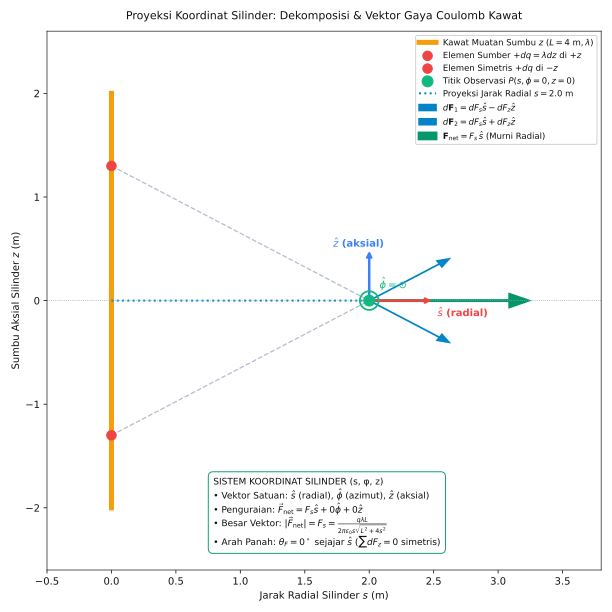

In [6]:
# Diagram Proyeksi Vektor 2D: Geometri Kawat Bermuatan & Penguraian Medan (Koordinat Silinder)
fig, ax = plt.subplots(dpi=120)

L_val = 4.0
s_val = 2.0
zp_pos = 1.3

# Kawat muatan di sumbu aksial z
ax.plot([0, 0], [-L_val/2, L_val/2], color='#f59e0b', linewidth=5, label=r'Kawat Muatan Sumbu $z$ ($L=4\text{ m}, \lambda$)')
ax.scatter([0], [zp_pos], color='#ef4444', s=90, zorder=6, label=r'Elemen Sumber $+dq = \lambda dz$ di $+z$')
ax.scatter([0], [-zp_pos], color='#ef4444', s=90, zorder=6, label=r'Elemen Simetris $+dq$ di $-z$')

# Titik observasi muatan uji q di koordinat silinder (s, phi=0, z=0)
ax.scatter([s_val], [0], color='#10b981', s=120, zorder=7, label=r'Titik Observasi $P(s, \phi=0, z=0)$')

# Proyeksi koordinat silinder: Jarak radial s dan garis jarak separasi
ax.plot([0, s_val], [0, 0], color='#0284c7', ls=':', lw=2, label=r'Proyeksi Jarak Radial $s = 2.0\text{ m}$')
ax.plot([0, s_val], [zp_pos, 0], color='#94a3b8', ls='--', lw=1.3, alpha=0.7)
ax.plot([0, s_val], [-zp_pos, 0], color='#94a3b8', ls='--', lw=1.3, alpha=0.7)

# Triad Vektor Satuan Silinder lokal di titik observasi P
# 1. Basis radial s_hat
ax.annotate('', xy=(s_val + 0.5, 0), xytext=(s_val, 0),
            arrowprops=dict(arrowstyle="->", color='#ef4444', lw=2.5))
ax.text(s_val + 0.53, -0.15, r'$\hat{s}$ (radial)', color='#ef4444', fontweight='bold', fontsize=10)

# 2. Basis aksial z_hat
ax.annotate('', xy=(s_val, 0.5), xytext=(s_val, 0),
            arrowprops=dict(arrowstyle="->", color='#3b82f6', lw=2.5))
ax.text(s_val - 0.28, 0.52, r'$\hat{z}$ (aksial)', color='#3b82f6', fontweight='bold', fontsize=10)

# 3. Basis azimut phi_hat (menembus bidang keluar)
ax.scatter([s_val], [0], facecolors='none', edgecolors='#10b981', s=350, lw=1.8, zorder=8)
ax.text(s_val + 0.08, 0.12, r'$\hat{\phi} = \odot$', color='#10b981', fontweight='bold', fontsize=10)

# Penguraian vektor gaya Coulomb dF
theta = np.arctan2(zp_pos, s_val)
dF = 0.65
ax.arrow(s_val, 0, dF*np.cos(theta), -dF*np.sin(theta), head_width=0.07, head_length=0.09,
         fc='#0284c7', ec='#0284c7', lw=1.6, label=r'$d\mathbf{F}_1 = dF_s\hat{s} - dF_z\hat{z}$')
ax.arrow(s_val, 0, dF*np.cos(theta), dF*np.sin(theta), head_width=0.07, head_length=0.09,
         fc='#0284c7', ec='#0284c7', lw=1.6, label=r'$d\mathbf{F}_2 = dF_s\hat{s} + dF_z\hat{z}$')

# Resultan total murni arah radial
ax.arrow(s_val, 0, 2*dF*np.cos(theta), 0, head_width=0.12, head_length=0.14,
         fc='#059669', ec='#059669', lw=2.8, label=r'$\mathbf{F}_{\text{net}} = F_s\,\hat{s}$ (Murni Radial)')

# Info card: Sistem Koordinat, Vektor Satuan, Besar Vektor, dan Arah Panah
info_txt = (
    "SISTEM KOORDINAT SILINDER (s, φ, z)\n"
    r"• Vektor Satuan: $\hat{s}$ (radial), $\hat{\phi}$ (azimut), $\hat{z}$ (aksial)" + "\n"
    r"• Penguraian: $\vec{F}_{\mathrm{net}} = F_s\hat{s} + 0\hat{\phi} + 0\hat{z}$" + "\n"
    r"• Besar Vektor: $|\vec{F}_{\mathrm{net}}| = F_s = \frac{q\lambda L}{2\pi\epsilon_0 s\sqrt{L^2+4s^2}}$" + "\n"
    r"• Arah Panah: $\theta_F = 0^\circ$ sejajar $\hat{s}$ ($\sum dF_z = 0$ simetris)"
)
ax.text(0.3, 0.04, info_txt, transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#059669', alpha=0.92),
        va='bottom', ha='left')

ax.set_title('Proyeksi Koordinat Silinder: Dekomposisi & Vektor Gaya Coulomb Kawat', fontsize=11, color='#111111', pad=12)
ax.set_xlabel('Jarak Radial Silinder $s$ (m)', fontsize=10)
ax.set_ylabel('Sumbu Aksial Silinder $z$ (m)', fontsize=10)
ax.set_xlim(-0.5, 3.8)
ax.set_ylim(-2.6, 2.6)
ax.axhline(0, color='#94a3b8', lw=0.8, ls=':')
ax.legend(loc='upper right', framealpha=0.88, facecolor='white', edgecolor='#cccccc', fontsize=8.5)
plt.tight_layout()
plt.show()


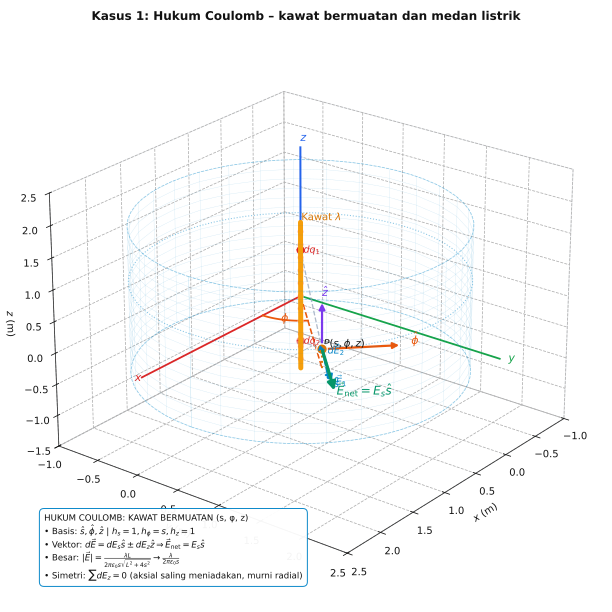

In [7]:
# Visualisasi 3D: Kasus 1: Hukum Coulomb – kawat bermuatan dan medan listrik
def plot_wire_scene(title="Proyeksi Koordinat Silinder: Hukum Coulomb & Medan Listrik Kawat 3D"):
    """Visualisasi Proyeksi 3D Hukum Coulomb pada Kawat Lurus Bermuatan (Koordinat Silinder)."""
    fig = plt.figure(dpi=120)
    ax = fig.add_subplot(111, projection='3d')
    setup_3d_pane(ax, xlim=(-1.0, 2.5), ylim=(-1.0, 2.5), zlim=(-1.5, 2.5), axis_len=2.4)
    
    # 1. Kawat lurus bermuatan pada sumbu z
    L = 2.4
    ax.plot([0, 0], [0, 0], [-L/2, L/2], color='#f59e0b', lw=5.0, solid_capstyle='round', zorder=5)
    z_beads = np.linspace(-L/2 + 0.15, L/2 - 0.15, 11)
    ax.scatter(np.zeros_like(z_beads), np.zeros_like(z_beads), z_beads, color='#ef4444', s=35, zorder=6, edgecolors='white', lw=0.5)
    ax.text(0.05, 0.05, L/2 + 0.08, r'$\text{Kawat } \lambda$', color='#d97706', fontweight='bold', fontsize=10)
    
    # 2. Permukaan silinder proyeksi transparan (wireframe)
    s0 = 1.7
    phi0 = np.pi / 4.0
    z0 = 0.3
    
    zc = np.linspace(-L/2, L/2, 16)
    phic = np.linspace(0, 2*np.pi, 32)
    PHIC, ZC = np.meshgrid(phic, zc)
    XC = s0 * np.cos(PHIC)
    YC = s0 * np.sin(PHIC)
    ax.plot_wireframe(XC, YC, ZC, color='#0284c7', lw=0.35, alpha=0.18)
    
    # Lingkaran alas & atas silinder
    phi_circ = np.linspace(0, 2*np.pi, 60)
    ax.plot(s0*np.cos(phi_circ), s0*np.sin(phi_circ), -L/2, color='#0284c7', lw=0.8, ls='--', alpha=0.4)
    ax.plot(s0*np.cos(phi_circ), s0*np.sin(phi_circ), L/2, color='#0284c7', lw=0.8, ls='--', alpha=0.4)
    ax.plot(s0*np.cos(phi_circ), s0*np.sin(phi_circ), z0, color='#0284c7', lw=1.1, ls=':', alpha=0.45)
    
    # 3. Titik Observasi P(s, phi, z)
    xp = s0 * np.cos(phi0)
    yp = s0 * np.sin(phi0)
    zp = z0
    ax.scatter([xp], [yp], [zp], color='#d97706', s=110, zorder=15, edgecolors='white', lw=1.2)
    ax.text(xp+0.08, yp+0.08, zp+0.12, r'$P(s, \phi, z)$', color='#111111', fontweight='bold', fontsize=10)
    
    # Proyeksi silinder: garis drop ke xy, garis radial di xy, busur phi
    ax.plot([xp, xp], [yp, yp], [0, zp], color='#d97706', ls=':', lw=2.0)
    ax.plot([0, xp], [0, yp], [0, 0], color='#ea580c', ls='--', lw=1.6)
    arc_phi = np.linspace(0, phi0, 25)
    ax.plot(0.6*np.cos(arc_phi), 0.6*np.sin(arc_phi), 0, color='#ea580c', lw=1.8)
    ax.text(0.7*np.cos(phi0/2), 0.7*np.sin(phi0/2), 0.04, r'$\phi$', color='#ea580c', fontweight='bold', fontsize=11)
    
    # 4. Elemen sumber simetris +dq1 di +z' dan +dq2 di -z'
    zp_src = 0.75
    p_src1 = np.array([0.0, 0.0, zp_src])
    p_src2 = np.array([0.0, 0.0, -zp_src])
    ax.scatter([0, 0], [0, 0], [zp_src, -zp_src], color='#dc2626', s=85, zorder=12, edgecolors='white', lw=1.0)
    ax.text(0.08, 0, zp_src, r'$+dq_1$', color='#dc2626', fontweight='bold', fontsize=9.5)
    ax.text(0.08, 0, -zp_src, r'$+dq_2$', color='#dc2626', fontweight='bold', fontsize=9.5)
    
    # Garis vektor separasi xi_1 dan xi_2
    p_obs = np.array([xp, yp, zp])
    ax.plot([0, xp], [0, yp], [zp_src, zp], color='#94a3b8', ls='--', lw=1.3, alpha=0.75)
    ax.plot([0, xp], [0, yp], [-zp_src, zp], color='#94a3b8', ls='--', lw=1.3, alpha=0.75)
    
    # 5. Triad Basis Silinder di P
    u_len = 0.75
    s_hat = np.array([np.cos(phi0), np.sin(phi0), 0.0])
    phi_hat = np.array([-np.sin(phi0), np.cos(phi0), 0.0])
    z_hat = np.array([0.0, 0.0, 1.0])
    
    ax.add_artist(Arrow3D([xp, xp+u_len*s_hat[0]], [yp, yp+u_len*s_hat[1]], [zp, zp+u_len*s_hat[2]],
                          mutation_scale=12, color='#0284c7', arrowstyle='-|>', lw=2.2))
    ax.text(xp+u_len*s_hat[0]+0.06, yp+u_len*s_hat[1]+0.06, zp, r'$\hat{s}$', color='#0284c7', fontweight='bold', fontsize=11)
    
    ax.add_artist(Arrow3D([xp, xp+u_len*phi_hat[0]], [yp, yp+u_len*phi_hat[1]], [zp, zp+u_len*phi_hat[2]],
                          mutation_scale=12, color='#ea580c', arrowstyle='-|>', lw=2.2))
    ax.text(xp+u_len*phi_hat[0]-0.08, yp+u_len*phi_hat[1]+0.06, zp, r'$\hat{\phi}$', color='#ea580c', fontweight='bold', fontsize=11)
    
    ax.add_artist(Arrow3D([xp, xp], [yp, yp], [zp, zp+u_len],
                          mutation_scale=12, color='#7c3aed', arrowstyle='-|>', lw=2.2))
    ax.text(xp, yp, zp+u_len+0.08, r'$\hat{z}$', color='#7c3aed', fontweight='bold', fontsize=11)
    
    # 6. Arah-arah Vektor Medan Diferensial & Pembatalan Komponen Aksial
    dE1 = (p_obs - p_src1) / np.linalg.norm(p_obs - p_src1)**3
    dE2 = (p_obs - p_src2) / np.linalg.norm(p_obs - p_src2)**3
    scale_dE = 0.55 / np.linalg.norm(dE1)
    v_dE1 = dE1 * scale_dE
    v_dE2 = dE2 * scale_dE
    
    ax.add_artist(Arrow3D([xp, xp+v_dE1[0]], [yp, yp+v_dE1[1]], [zp, zp+v_dE1[2]],
                          mutation_scale=10, color='#0284c7', arrowstyle='-|>', lw=1.6, ls='--'))
    ax.text(xp+v_dE1[0]+0.04, yp+v_dE1[1]+0.04, zp+v_dE1[2], r'$d\vec{E}_1$', color='#0284c7', fontsize=9.5)
    
    ax.add_artist(Arrow3D([xp, xp+v_dE2[0]], [yp, yp+v_dE2[1]], [zp, zp+v_dE2[2]],
                          mutation_scale=10, color='#0284c7', arrowstyle='-|>', lw=1.6, ls='--'))
    ax.text(xp+v_dE2[0]+0.04, yp+v_dE2[1]+0.04, zp+v_dE2[2], r'$d\vec{E}_2$', color='#0284c7', fontsize=9.5)
    
    # 7. Vektor Resultan Medan Listrik Netto (Murni Radial)
    E_net_len = 0.95
    ax.add_artist(Arrow3D([xp, xp+E_net_len*s_hat[0]], [yp, yp+E_net_len*s_hat[1]], [zp, zp],
                          mutation_scale=16, color='#059669', arrowstyle='-|>', lw=3.2))
    ax.text(xp+E_net_len*s_hat[0]+0.08, yp+E_net_len*s_hat[1]+0.08, zp+0.05,
            r'$\vec{E}_{\mathrm{net}} = E_s\hat{s}$', color='#059669', fontweight='bold', fontsize=12)
    
    # 8. Info Card
    card_wire = (
        "HUKUM COULOMB: KAWAT BERMUATAN (s, φ, z)\n"
        r"• Basis: $\hat{s}, \hat{\phi}, \hat{z}$ | $h_s=1, h_\phi=s, h_z=1$" + "\n"
        r"• Vektor: $d\vec{E} = dE_s\hat{s} \pm dE_z\hat{z} \Rightarrow \vec{E}_{\mathrm{net}} = E_s\hat{s}$" + "\n"
        r"• Besar: $|\vec{E}| = \frac{\lambda L}{2\pi\epsilon_0 s\sqrt{L^2+4s^2}} \to \frac{\lambda}{2\pi\epsilon_0 s}$" + "\n"
        r"• Simetri: $\sum dE_z = 0$ (aksial saling meniadakan, murni radial)"
    )
    ax.text2D(0.04, 0.04, card_wire, transform=ax.transAxes, fontsize=8.6,
              bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#0284c7', alpha=0.95),
              color='#111111')
    
    ax.set_title(title, color='#111111', fontsize=12, pad=12, fontweight='bold')
    ax.view_init(elev=24, azim=38)
    plt.tight_layout()
    plt.show()
    plt.close()

plot_wire_scene("Kasus 1: Hukum Coulomb – kawat bermuatan dan medan listrik")


---
## 3. Kasus Analitik 2: Medan Listrik dan Hukum Gauss (Fluks Listrik & Simetri Tinggi)

**Makna dan penggunaan Teorema Divergensi.** Untuk volume $\mathcal V$ dengan permukaan tertutup $\mathcal S=\partial\mathcal V$, $\oint_{\mathcal S}\mathbf E\cdot d\mathbf a=\int_{\mathcal V}\nabla\cdot\mathbf E\,d\tau=Q_{\rm enc}/\epsilon_0$. Maka fluks bersih ditentukan muatan yang dilingkupi. Muatan di luar dapat menghasilkan medan pada permukaan, tetapi fluks bersih kontribusinya nol. Hukum Gauss berlaku untuk permukaan tertutup apa pun; simetri diperlukan agar fluks dapat digunakan dengan mudah untuk mencari $\mathbf E$. Fluks nol tidak berarti medan nol.
Pada bola seragam, $E_r\propto r$ di dalam sehingga $r^{-2}\frac{d}{dr}(r^2E_r)=\rho_0/\epsilon_0$; di luar $E_r\propto r^{-2}$ sehingga divergensi nol. Curl memberi informasi independen: $\nabla\times\mathbf E=0$ pada daerah elektrostatik yang reguler. Hukum Gauss saja tidak menentukan medan secara unik; sifat curl dan kondisi batas juga berperan. Di titik singular seperti muatan titik, persamaan diferensial dipahami secara distribusi atau integral diterapkan dengan memperhitungkan muatan singular tersebut.

> **Kaitan dengan Griffiths:** Bab 2 §2.2 menekankan bahwa Hukum Gauss berlaku untuk setiap permukaan tertutup, tetapi biasanya memudahkan perhitungan $\mathbf{E}$ hanya ketika simetri sumber menentukan arah dan keseragaman medan pada permukaan Gaussian. Fluks total saja tidak menentukan medan lokal tanpa informasi simetri.


### 3.1 Penurunan Matematis Eksak
Hukum Gauss menghubungkan fluks medan listrik total yang menembus permukaan tertutup $\mathcal{S} = \partial \mathcal{V}$ dengan muatan total $Q_{\text{enc}}$ yang dilingkupi:
$$\Phi_E = \oint_{\mathcal{S}} \mathbf{E} \cdot d\mathbf{a} = \frac{Q_{\text{enc}}}{\epsilon_0}$$

Berdasarkan Teorema Divergensi Gauss, hubungan integral ini ditransformasikan ke bentuk diferensial:
$$\oint_{\mathcal{S}} \mathbf{E} \cdot d\mathbf{a} = \int_{\mathcal{V}} (\nabla \cdot \mathbf{E}) d\tau = \frac{1}{\epsilon_0} \int_{\mathcal{V}} \rho d\tau \implies \nabla \cdot \mathbf{E} = \frac{\rho}{\epsilon_0}$$

#### Kasus Analitik: Bola Pejal Bermuatan Seragam
Tinjau sebuah bola isolator pejal beradius $R$ dengan muatan total $Q$ yang terdistribusi secara homogen dengan kerapatan muatan volume konstan $\rho_0 = \frac{Q}{\frac{4}{3}\pi R^3}$.

Pilih permukaan Gauss sferis konsentris beradius $r$. Karena simetri bola sempurna, medan listrik bersifat murni radial $\mathbf{E} = E(r) \hat{\mathbf{r}}$ dan magnitudonya konstan pada seluruh permukaan bola Gauss:
$$\oint_{\mathcal{S}} \mathbf{E} \cdot d\mathbf{a} = E(r) (4\pi r^2)$$

1. **Di Dalam Bola Pejal ($r \le R$):**
   $$Q_{\text{enc}} = \rho_0 \left(\frac{4}{3}\pi r^3\right) = Q \frac{r^3}{R^3}$$
   $$E_{\text{in}}(r) (4\pi r^2) = \frac{Q r^3}{\epsilon_0 R^3} \implies E_{\text{in}}(r) = \frac{Q r}{4\pi\epsilon_0 R^3} = \frac{\rho_0 r}{3\epsilon_0}$$
   Medan listrik di dalam bola tumbuh secara linear terhadap jarak radial $r$.

2. **Di Luar Bola Pejal ($r \ge R$):**
   $$Q_{\text{enc}} = Q$$
   $$E_{\text{out}}(r) (4\pi r^2) = \frac{Q}{\epsilon_0} \implies E_{\text{out}}(r) = \frac{Q}{4\pi\epsilon_0 r^2} = \frac{\rho_0 R^3}{3\epsilon_0 r^2}$$
   Medan listrik di luar bola meluruh sesuai hukum kuadrat terbalik (*inverse-square law*), identik dengan medan muatan titik yang terpusat di origin.

### 3.2 Penjelasan Fisis & Teorema Divergensi
Hukum Gauss lokal, $\nabla\cdot\mathbf{E}=\rho/\epsilon_0$, menghubungkan sumber muatan dengan divergensi medan; Teorema Divergensi menghubungkan bentuk lokal dan integralnya. Divergensi medan listrik di dalam bola adalah konstan: $\nabla \cdot \mathbf{E} = \frac{1}{r^2} \frac{\partial}{\partial r}(r^2 E_r) = \frac{\rho_0}{\epsilon_0}$. Di luar bola, kerapatan muatan lokal bernilai nol sehingga $\nabla \cdot \mathbf{E} = 0$. Pada batas $r = R$, medan listrik bersifat kontinu sempurna ($E_{\text{in}}(R) = E_{\text{out}}(R)$), namun turunan pertamanya mengalami diskontinuitas akibat lompatan kerapatan muatan $\Delta \rho = -\rho_0$.

### 3.3 Formulasi Persamaan Superposisi pada Medan Listrik & Hukum Gauss
1. **Superposisi Fluks Medan Listrik:**
   Linearitas operator integral memastikan bahwa jika suatu sistem tersusun atas beberapa sumber muatan berbeda, fluks listrik total merupakan penjumlahan aljabar dari fluks masing-masing sumber:
   $$\Phi_E = \oint_{\mathcal{S}} \left( \sum_{i=1}^N \mathbf{E}_i \right) \cdot d\mathbf{a} = \sum_{i=1}^N \oint_{\mathcal{S}} \mathbf{E}_i \cdot d\mathbf{a} = \frac{\sum_{i=1}^N Q_{\text{enc},i}}{\epsilon_0}$$

2. **Superposisi Kulit Sferis Konsentris (Teorema Kulit Newton):**
   Bola pejal dapat dipandang sebagai superposisi kontinu dari kulit-kulit sferis infinitesimal berjejari $r'$ dengan muatan $dq' = \rho_0 (4\pi r'^2 dr')$. Berdasarkan teorema kulit:
   - Kulit-kulit luar ($r' > r$) menghasilkan superposisi medan nol di titik $r$.
   - Kulit-kulit dalam ($r' \le r$) menghasilkan superposisi medan ekivalen dengan seluruh muatan bagian dalam terpusat di titik asal.
   Melalui integral superposisi kulit:
   $$\mathbf{E}(r) = \int_0^R d\mathbf{E}_{\text{kulit}} = \int_0^r \frac{\rho_0 (4\pi r'^2 dr')}{4\pi\epsilon_0 r^2} \hat{\mathbf{r}} + \int_r^R \mathbf{0} = \frac{\rho_0 r}{3\epsilon_0} \hat{\mathbf{r}}$$

3. **Aplikasi Superposisi pada Problem Rongga (*Spherical Cavity Problem*):**
   Tinjau sebuah bola pejal seragam beradius $R$ bermuatan $+\rho_0$ yang memiliki rongga sferis beradius $a$ yang digeser sejauh vektor $\mathbf{d}$ dari pusat bola. Melalui prinsip superposisi linear:
   $$\mathbf{E}_{\text{rongga}}(\mathbf{r}) = \mathbf{E}_{\text{bola penuh}}(\mathbf{r}, +\rho_0) + \mathbf{E}_{\text{bola rongga}}(\mathbf{r} - \mathbf{d}, -\rho_0)$$
   $$\mathbf{E}_{\text{rongga}}(\mathbf{r}) = \frac{\rho_0}{3\epsilon_0} \mathbf{r} + \frac{-\rho_0}{3\epsilon_0} (\mathbf{r} - \mathbf{d}) = \frac{\rho_0}{3\epsilon_0} \mathbf{d}$$
   Persamaan superposisi membuktikan secara elegan bahwa medan listrik di dalam sembarang rongga bola eksentrik bersifat **konstan dan homogen seragam** sempurna searah pergeseran $\mathbf{d}$!


In [8]:
# Verifikasi Simbolik SymPy: Hukum Gauss & Divergensi Medan Bola Pejal
r_sym, R_sym, Q_sym, rho0_sym, eps0_sym = sp.symbols('r R Q rho_0 epsilon_0', positive=True, real=True)

# Definisi medan listrik dalam dan luar
E_in_sym = (rho0_sym * r_sym) / (3 * eps0_sym)
E_out_sym = (rho0_sym * R_sym**3) / (3 * eps0_sym * r_sym**2)

# Divergensi koordinat bola: div(E) = (1/r^2) * d/dr (r^2 * E_r)
div_E_in = sp.simplify((1 / r_sym**2) * sp.diff(r_sym**2 * E_in_sym, r_sym))
div_E_out = sp.simplify((1 / r_sym**2) * sp.diff(r_sym**2 * E_out_sym, r_sym))

# Diskontinuitas turunan dE/dr di batas r = R
dE_in_dr = sp.diff(E_in_sym, r_sym).subs(r_sym, R_sym)
dE_out_dr = sp.diff(E_out_sym, r_sym).subs(r_sym, R_sym)
delta_dE_dr = sp.simplify(dE_out_dr - dE_in_dr)

print("=== VERIFIKASI SIMBOLIK SYMPY: HUKUM GAUSS & TEOREMA DIVERGENSI ===")
print(f"Divergensi di dalam bola (r < R) : div(E) = {div_E_in} (Sesuai Persamaan Maxwell: rho_0 / epsilon_0)")
print(f"Divergensi di luar bola (r > R)  : div(E) = {div_E_out} (Sesuai Ruang Hampa: 0)")
print(f"Kontinuitas E(R)                 : E_in(R) - E_out(R) = {sp.simplify(E_in_sym.subs(r_sym, R_sym) - E_out_sym.subs(r_sym, R_sym))}")
print(f"Lompatan Turunan [dE/dr] di r=R  : Delta(dE/dr) = {delta_dE_dr}")
print(f"Kesetaraan Fisis Lompatan        : -rho_0 / epsilon_0 = {-rho0_sym/eps0_sym}")
assert sp.simplify(delta_dE_dr - (-rho0_sym/eps0_sym)) == 0, "Lompatan fluks diferensial tidak konsisten!"
print("Verifikasi Diferensial Teorema Gauss: SUKSES SEMPURNA")


=== VERIFIKASI SIMBOLIK SYMPY: HUKUM GAUSS & TEOREMA DIVERGENSI ===
Divergensi di dalam bola (r < R) : div(E) = rho_0/epsilon_0 (Sesuai Persamaan Maxwell: rho_0 / epsilon_0)
Divergensi di luar bola (r > R)  : div(E) = 0 (Sesuai Ruang Hampa: 0)
Kontinuitas E(R)                 : E_in(R) - E_out(R) = 0
Lompatan Turunan [dE/dr] di r=R  : Delta(dE/dr) = -rho_0/epsilon_0
Kesetaraan Fisis Lompatan        : -rho_0 / epsilon_0 = -rho_0/epsilon_0
Verifikasi Diferensial Teorema Gauss: SUKSES SEMPURNA


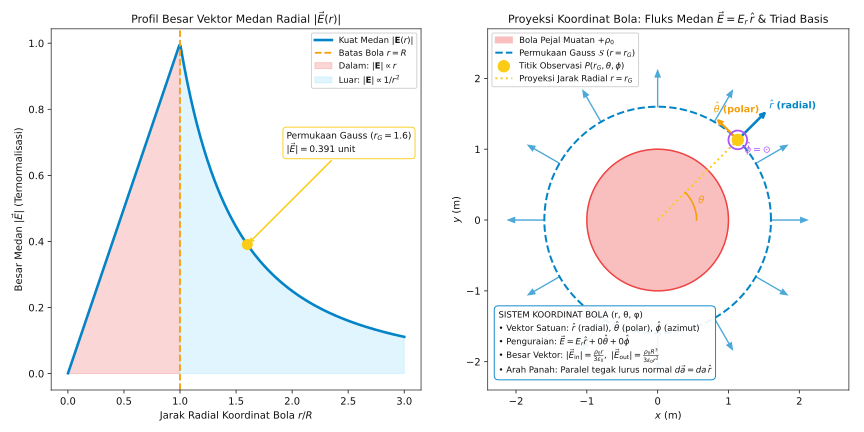

In [9]:
# Diagram Proyeksi Vektor 2D: Profil Medan Radial E(r) & Permukaan Gauss (Koordinat Bola)
fig, (ax1, ax2) = plt.subplots(1, 2, dpi=120, figsize=(12, 6))

R_val = 1.0
r_arr = np.linspace(0.001, 3.0, 300)
E_arr = np.where(r_arr <= R_val, r_arr / R_val**3, 1.0 / r_arr**2)

# Subplot 1: Kurva E(r) dengan anotasi nilai besar vektor
ax1.plot(r_arr, E_arr, color='#0284c7', lw=2.6, label=r'Kuat Medan $|\mathbf{E}(r)|$')
ax1.axvline(R_val, color='#f59e0b', ls='--', lw=1.8, label=r'Batas Bola $r = R$')
ax1.fill_between(r_arr[r_arr <= R_val], 0, E_arr[r_arr <= R_val], color='#ef4444', alpha=0.22, label=r'Dalam: $|\mathbf{E}| \propto r$')
ax1.fill_between(r_arr[r_arr >= R_val], 0, E_arr[r_arr >= R_val], color='#38bdf8', alpha=0.15, label=r'Luar: $|\mathbf{E}| \propto 1/r^2$')

r_eval = 1.6
E_eval = 1.0 / (r_eval**2)
ax1.scatter([r_eval], [E_eval], color='#facc15', s=100, zorder=6)
ax1.annotate(f'Permukaan Gauss ($r_G = {r_eval}$)\n$|\\vec{{E}}| = {E_eval:.3f}$ unit',
             xy=(r_eval, E_eval), xytext=(r_eval + 0.35, E_eval + 0.28),
             arrowprops=dict(arrowstyle="->", color='#facc15', lw=1.5),
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#facc15', alpha=0.9),
             color='#111111', fontsize=9)

ax1.set_title(r'Profil Besar Vektor Medan Radial $|\vec{E}(r)|$', fontsize=11, color='#111111')
ax1.set_xlabel('Jarak Radial Koordinat Bola $r/R$', fontsize=10)
ax1.set_ylabel(r'Besar Medan $|\vec{E}|$ (Ternormalisasi)', fontsize=10)
ax1.legend(loc='upper right', framealpha=0.88, facecolor='white', edgecolor='#cccccc', fontsize=8.5)

# Subplot 2: Penampang 2D Proyeksi Koordinat Bola (r, theta, phi)
theta_circ = np.linspace(0, 2*np.pi, 200)
ax2.fill(R_val*np.cos(theta_circ), R_val*np.sin(theta_circ), color='#ef4444', alpha=0.35, label=r'Bola Pejal Muatan $+\rho_0$')
ax2.plot(R_val*np.cos(theta_circ), R_val*np.sin(theta_circ), color='#ef4444', lw=1.5)
r_gauss = 1.6
ax2.plot(r_gauss*np.cos(theta_circ), r_gauss*np.sin(theta_circ), color='#0284c7', ls='--', lw=2.0, label=r'Permukaan Gauss $\mathcal{S}$ ($r=r_G$)')

# Titik observasi P di permukaan Gauss pada sudut theta_0 = 45 deg
th_p = np.pi / 4.0
xp = r_gauss * np.cos(th_p)
yp = r_gauss * np.sin(th_p)
ax2.scatter([xp], [yp], color='#facc15', s=130, zorder=7, label=r'Titik Observasi $P(r_G, \theta, \phi)$')

# Proyeksi radial & sudut polar
ax2.plot([0, xp], [0, yp], color='#facc15', ls=':', lw=2, label=r'Proyeksi Jarak Radial $r = r_G$')
arc_th = np.linspace(0, th_p, 40)
ax2.plot(0.55*np.cos(arc_th), 0.55*np.sin(arc_th), color='#f59e0b', lw=1.6)
ax2.text(0.62*np.cos(th_p/2), 0.62*np.sin(th_p/2), r'$\theta$', color='#f59e0b', fontsize=10, fontweight='bold')

# Triad Vektor Satuan Bola di Titik P
# 1. r_hat (radial keluar)
ax2.annotate('', xy=(xp + 0.6*np.cos(th_p), yp + 0.6*np.sin(th_p)), xytext=(xp, yp),
             arrowprops=dict(arrowstyle="->", color='#0284c7', lw=2.6))
ax2.text(xp + 0.63*np.cos(th_p), yp + 0.63*np.sin(th_p), r'$\hat{r}$ (radial)', color='#0284c7', fontweight='bold', fontsize=9.5)

# 2. theta_hat (polar tegak lurus r_hat)
ax2.annotate('', xy=(xp - 0.45*np.sin(th_p), yp + 0.45*np.cos(th_p)), xytext=(xp, yp),
             arrowprops=dict(arrowstyle="->", color='#f59e0b', lw=2.2))
ax2.text(xp - 0.48*np.sin(th_p), yp + 0.48*np.cos(th_p) + 0.05, r'$\hat{\theta}$ (polar)', color='#f59e0b', fontweight='bold', fontsize=9.5)

# 3. phi_hat (azimut menembus bidang)
ax2.scatter([xp], [yp], facecolors='none', edgecolors='#a855f7', s=350, lw=1.8, zorder=8)
ax2.text(xp + 0.1, yp - 0.18, r'$\hat{\phi} = \odot$', color='#a855f7', fontweight='bold', fontsize=9.5)

# Vektor medan listrik menembus normal permukaan
for th in np.linspace(0, 2*np.pi, 12, endpoint=False):
    if np.abs(th - th_p) > 0.1:
        ax2.arrow(r_gauss*np.cos(th), r_gauss*np.sin(th), 0.42*np.cos(th), 0.42*np.sin(th),
                  head_width=0.07, head_length=0.09, fc='#0284c7', ec='#0284c7', lw=1.3, alpha=0.7)

# Info card: Koordinat Bola, Vektor Satuan, Besar Medan, dan Arah Panah
info_gauss = (
    "SISTEM KOORDINAT BOLA (r, θ, φ)\n"
    r"• Vektor Satuan: $\hat{r}$ (radial), $\hat{\theta}$ (polar), $\hat{\phi}$ (azimut)" + "\n"
    r"• Penguraian: $\vec{E} = E_r\hat{r} + 0\hat{\theta} + 0\hat{\phi}$" + "\n"
    r"• Besar Vektor: $|\vec{E}_{\mathrm{in}}| = \frac{\rho_0 r}{3\epsilon_0},\ |\vec{E}_{\mathrm{out}}| = \frac{\rho_0 R^3}{3\epsilon_0 r^2}$" + "\n"
    r"• Arah Panah: Paralel tegak lurus normal $d\vec{a} = da\,\hat{r}$"
)
ax2.text(0.03, 0.04, info_gauss, transform=ax2.transAxes, fontsize=8.5,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#0284c7', alpha=0.92),
         va='bottom', ha='left')

ax2.set_aspect('equal')
ax2.set_title(r'Proyeksi Koordinat Bola: Fluks Medan $\vec{E} = E_r\,\hat{r}$ & Triad Basis', fontsize=11, color='#111111')
ax2.set_xlabel('$x$ (m)', fontsize=10)
ax2.set_ylabel('$y$ (m)', fontsize=10)
ax2.set_xlim(-2.4, 2.7)
ax2.set_ylim(-2.4, 2.7)
ax2.legend(loc='upper left', framealpha=0.88, facecolor='white', edgecolor='#cccccc', fontsize=8.5)

plt.tight_layout()
plt.show()


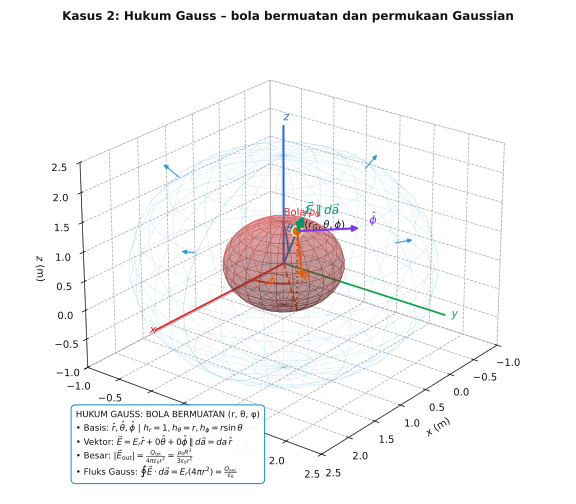

In [10]:
# Visualisasi 3D: Kasus 2: Hukum Gauss – bola bermuatan dan permukaan Gaussian
def plot_gauss_scene(title="Proyeksi Koordinat Bola: Hukum Gauss & Fluks Medan Listrik 3D"):
    """Visualisasi Proyeksi 3D Hukum Gauss pada Bola Pejal Bermuatan (Koordinat Bola)."""
    fig = plt.figure(dpi=120, figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')
    setup_3d_pane(ax, xlim=(-1.0, 2.5), ylim=(-1.0, 2.5), zlim=(-1.0, 2.5), axis_len=2.4)
    
    # 1. Bola Sumber Bermuatan (R = 0.75)
    R_src = 0.75
    u = np.linspace(0, 2 * np.pi, 24)
    v = np.linspace(0, np.pi, 16)
    xs = R_src * np.outer(np.cos(u), np.sin(v))
    ys = R_src * np.outer(np.sin(u), np.sin(v))
    zs = R_src * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(xs, ys, zs, color='#ef4444', alpha=0.28, edgecolors='#f87171', lw=0.2)
    ax.text(0, 0, R_src + 0.1, r'$\text{Bola } \rho_0$', color='#dc2626', fontweight='bold', fontsize=10)
    
    # 2. Permukaan Gauss Sferis (r_G = 1.9)
    r_G = 1.9
    th0, phi0 = np.pi/4, np.pi/4
    xg = r_G * np.outer(np.cos(u), np.sin(v))
    yg = r_G * np.outer(np.sin(u), np.sin(v))
    zg = r_G * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(xg, yg, zg, color='#0284c7', lw=0.4, alpha=0.22)
    
    # 3. Titik Observasi di Permukaan Gauss
    xp = r_G * np.sin(th0) * np.cos(phi0)
    yp = r_G * np.sin(th0) * np.sin(phi0)
    zs_p = r_G * np.cos(th0)
    ax.scatter([xp], [yp], [zs_p], color='#d97706', s=110, zorder=15, edgecolors='white', lw=1.2)
    ax.text(xp+0.08, yp+0.08, zs_p+0.12, r'$P(r_G, \theta, \phi)$', color='#111111', fontweight='bold', fontsize=10)
    
    # Proyeksi bola: garis radial, drop line, garis xy, busur theta & phi
    ax.plot([0, xp], [0, yp], [0, zs_p], color='#0284c7', ls='-', lw=2.0)
    ax.plot([xp, xp], [yp, yp], [0, zs_p], color='#d97706', ls=':', lw=2.0)
    ax.plot([0, xp], [0, yp], [0, 0], color='#ea580c', ls='--', lw=1.6)
    
    arc_th = np.linspace(0, th0, 20)
    ax.plot(0.7*np.sin(arc_th)*np.cos(phi0), 0.7*np.sin(arc_th)*np.sin(phi0), 0.7*np.cos(arc_th), color='#0284c7', lw=1.8)
    ax.text(0.8*np.sin(th0/2)*np.cos(phi0), 0.8*np.sin(th0/2)*np.sin(phi0), 0.8*np.cos(th0/2), r'$\theta$', color='#0284c7', fontweight='bold', fontsize=11)
    
    arc_phi = np.linspace(0, phi0, 20)
    ax.plot(0.6*np.cos(arc_phi), 0.6*np.sin(arc_phi), 0, color='#ea580c', lw=1.8)
    ax.text(0.7*np.cos(phi0/2), 0.7*np.sin(phi0/2), 0.04, r'$\phi$', color='#ea580c', fontweight='bold', fontsize=11)
    
    # 4. Triad Basis Bola di P
    u_len = 0.75
    rx = np.sin(th0)*np.cos(phi0); ry = np.sin(th0)*np.sin(phi0); rz = np.cos(th0)
    tx = np.cos(th0)*np.cos(phi0); ty = np.cos(th0)*np.sin(phi0); tz = -np.sin(th0)
    px = -np.sin(phi0); py = np.cos(phi0); pz = 0.0
    
    ax.add_artist(Arrow3D([xp, xp+u_len*rx], [yp, yp+u_len*ry], [zs_p, zs_p+u_len*rz],
                          mutation_scale=12, color='#0284c7', arrowstyle='-|>', lw=2.2))
    ax.text(xp+u_len*rx+0.06, yp+u_len*ry+0.06, zs_p+u_len*rz+0.06, r'$\hat{r}$', color='#0284c7', fontweight='bold', fontsize=11)
    
    ax.add_artist(Arrow3D([xp, xp+u_len*tx], [yp, yp+u_len*ty], [zs_p, zs_p+u_len*tz],
                          mutation_scale=12, color='#ea580c', arrowstyle='-|>', lw=2.2))
    ax.text(xp+u_len*tx+0.06, yp+u_len*ty+0.06, zs_p+u_len*tz+0.06, r'$\hat{\theta}$', color='#ea580c', fontweight='bold', fontsize=11)
    
    ax.add_artist(Arrow3D([xp, xp+u_len*px], [yp, yp+u_len*py], [zs_p, zs_p+u_len*pz],
                          mutation_scale=12, color='#7c3aed', arrowstyle='-|>', lw=2.2))
    ax.text(xp+u_len*px-0.08, yp+u_len*py+0.06, zs_p+0.06, r'$\hat{\phi}$', color='#7c3aed', fontweight='bold', fontsize=11)
    
    # 5. Panah Fluks E || da (Kollinear Normal Radial)
    E_len = 0.95
    ax.add_artist(Arrow3D([xp, xp+E_len*rx], [yp, yp+E_len*ry], [zs_p, zs_p+E_len*rz],
                          mutation_scale=16, color='#059669', arrowstyle='-|>', lw=3.2))
    ax.text(xp+E_len*rx+0.08, yp+E_len*ry+0.08, zs_p+E_len*rz+0.06,
            r'$\vec{E} \parallel d\vec{a}$', color='#059669', fontweight='bold', fontsize=12)
    
    # 6. Tambahan panah fluks di beberapa titik permukaan Gauss
    for angle in [0, np.pi/2, np.pi, 3*np.pi/2]:
        p_fl = np.array([r_G*np.cos(angle)*np.sin(np.pi/3), r_G*np.sin(angle)*np.sin(np.pi/3), r_G*np.cos(np.pi/3)])
        u_fl = p_fl / np.linalg.norm(p_fl) * 0.35
        ax.add_artist(Arrow3D([p_fl[0], p_fl[0]+u_fl[0]], [p_fl[1], p_fl[1]+u_fl[1]], [p_fl[2], p_fl[2]+u_fl[2]],
                              mutation_scale=9, color='#0284c7', arrowstyle='-|>', lw=1.3, alpha=0.7))
    
    card_gauss = (
        "HUKUM GAUSS: BOLA BERMUATAN (r, θ, φ)\n"
        r"• Basis: $\hat{r}, \hat{\theta}, \hat{\phi}$ | $h_r=1, h_\theta=r, h_\phi=r\sin\theta$" + "\n"
        r"• Vektor: $\vec{E} = E_r\hat{r} + 0\hat{\theta} + 0\hat{\phi} \parallel d\vec{a} = da\,\hat{r}$" + "\n"
        r"• Besar: $|\vec{E}_{\mathrm{out}}| = \frac{Q_{\mathrm{tot}}}{4\pi\epsilon_0 r^2} = \frac{\rho_0 R^3}{3\epsilon_0 r^2}$" + "\n"
        r"• Fluks Gauss: $\oint \vec{E}\cdot d\vec{a} = E_r (4\pi r^2) = \frac{Q_{\mathrm{enc}}}{\epsilon_0}$"
    )
    ax.text2D(0.04, 0.04, card_gauss, transform=ax.transAxes, fontsize=8.6,
              bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#0284c7', alpha=0.95),
              color='#111111')
    
    ax.set_title(title, color='#111111', fontsize=12, pad=12, fontweight='bold')
    ax.view_init(elev=24, azim=38)
    plt.tight_layout()
    plt.show()
    plt.close()

plot_gauss_scene("Kasus 2: Hukum Gauss – bola bermuatan dan permukaan Gaussian")


---
## 4. Kasus Analitik 3: Potensial Listrik dan Energi Potensial (Persamaan Laplace & Poisson)

**Curl, Teorema Stokes, dan potensial.** Teorema Stokes mengubah $\nabla\times\mathbf E=0$ menjadi $\oint_C\mathbf E\cdot d\mathbf l=\int_{\mathcal S}(\nabla\times\mathbf E)\cdot d\mathbf a=0$. Karena itu kerja medan antara dua titik bebas lintasan dan $V(b)-V(a)=-\int_a^b\mathbf E\cdot d\mathbf l$. Sebaliknya, jika $\mathbf E=-\nabla V$, identitas $\nabla\times(\nabla V)=0$ memastikan curl medan lenyap.
Pernyataan global tersebut mengandaikan medan cukup mulus pada domain dan, untuk potensial tunggal global, domain terhubung sederhana (tidak ada singularitas/lubang yang dikecualikan). Menggabungkan $\mathbf E=-\nabla V$ dengan $\nabla\cdot\mathbf E=\rho/\epsilon_0$ menghasilkan Poisson $\nabla^2V=-\rho/\epsilon_0$; pada daerah bebas muatan diperoleh Laplace $\nabla^2V=0$. Jadi curl nol memberi representasi potensial, sedangkan divergensi menentukan sumber bagi potensial.

> **Kaitan dengan Griffiths:** Bab 2 §§2.3–2.4 menghubungkan potensial dengan kerja medan konservatif dan energi. Bab 3 §3.1 menggunakan $\nabla^2V=-\rho/\epsilon_0$ (Poisson) serta kasus tanpa sumber $\nabla^2V=0$ (Laplace); nilai nol potensial di tak hingga hanya dipilih bila integral dan kondisi batas mengizinkannya.


### 4.1 Penurunan Matematis Eksak
Karena curl medan elektrostatik identik nol ($\nabla \times \mathbf{E} = \mathbf{0}$), integral garis $\int_{\mathbf{a}}^{\mathbf{b}} \mathbf{E} \cdot d\mathbf{l}$ bersifat independen terhadap lintasan. Kita dapat mendefinisikan **potensial skalar** $V(\mathbf{r})$ dengan titik acuan nol di tak hingga:
$$V(\mathbf{r}) = -\int_{\infty}^{\mathbf{r}} \mathbf{E} \cdot d\mathbf{l} \iff \mathbf{E} = -\nabla V$$

#### Potensial Skalar Bola Pejal Bermuatan Seragam
1. **Di Luar Bola ($r \ge R$):**
   $$V_{\text{out}}(r) = -\int_{\infty}^r \frac{Q}{4\pi\epsilon_0 r'^2} dr' = \frac{Q}{4\pi\epsilon_0 r}$$
2. **Di Dalam Bola ($r \le R$):**
   $$V_{\text{in}}(r) = V_{\text{out}}(R) - \int_R^r \frac{Q r'}{4\pi\epsilon_0 R^3} dr' = \frac{Q}{8\pi\epsilon_0 R} \left( 3 - \frac{r^2}{R^2} \right)$$

Pada pusat bola ($r = 0$), potensial mencapai nilai puncak $V(0) = \frac{3}{2} V(R)$.

#### Energi Elektrostatik Total yang Tersimpan
Energi yang dibutuhkan untuk merakit distribusi muatan elektrostatik kontinu dihitung melalui:
$$W = \frac{1}{2} \int_{\mathcal{V}} \rho V d\tau = \frac{\epsilon_0}{2} \int_{\text{seluruh ruang}} E^2 d\tau = \frac{3}{5} \frac{Q^2}{4\pi\epsilon_0 R}$$

### 4.2 Penjelasan Fisis & Hubungan dengan Persamaan Laplace
Di luar bola, $\rho = 0$, sehingga potensial memenuhi **Persamaan Laplace**: $\nabla^2 V = 0$. Di daerah bebas muatan, solusi Laplace bersifat harmonik: nilainya memenuhi sifat nilai rata-rata dan tidak mempunyai maksimum atau minimum lokal kecuali jika konstan. Ini adalah prinsip nilai maksimum; konsekuensi terkait kestabilan muatan uji dikenal sebagai teorema Earnshaw.

### 4.3 Formulasi Persamaan Superposisi: Skalar Potensial vs Non-Linearitas Energi
1. **Keunggulan Superposisi Skalar Potensial Listrik:**
   Karena potensial $V$ adalah besaran skalar, prinsip superposisi potensial skalar tidak memerlukan proyeksi vektor trigonometri:
   $$V(\mathbf{r}) = \sum_{i=1}^N V_i(\mathbf{r}) = \frac{1}{4\pi\epsilon_0} \sum_{i=1}^N \frac{q_i}{|\mathbf{r} - \mathbf{r}_i|}, \quad V(\mathbf{r}) = \frac{1}{4\pi\epsilon_0} \int \frac{\rho(\mathbf{r}')}{|\mathbf{r} - \mathbf{r}'|} d\tau'$$
   Linearitas operator diferensial gradien menjamin bahwa medan listrik hasil gradien potensial gabungan identik dengan superposisi medan vektor:
   $$\mathbf{E}(\mathbf{r}) = -\nabla V(\mathbf{r}) = -\nabla \left( \sum_i V_i \right) = \sum_i (-\nabla V_i) = \sum_i \mathbf{E}_i(\mathbf{r})$$

2. **Non-Linearitas Superposisi Energi Elektrostatik:**
   *Catatan Fundamental:* Prinsip superposisi **TIDAK berlaku secara linear untuk energi elektrostatik total**. Karena kerapatan energi elektrostatik sebanding dengan kuadrat medan ($u = \frac{1}{2}\epsilon_0 E^2$):
   $$W_{\text{total}} = \frac{\epsilon_0}{2} \int |\mathbf{E}_1 + \mathbf{E}_2|^2 d\tau = \frac{\epsilon_0}{2} \int \left( E_1^2 + E_2^2 + 2 \mathbf{E}_1 \cdot \mathbf{E}_2 \right) d\tau$$
   $$W_{\text{total}} = W_1 + W_2 + W_{12}$$
   di mana suku silang (*cross term*) $W_{12}$ merepresentasikan **energi interaksi elektrostatik mutual**:
   $$W_{12} = \epsilon_0 \int \mathbf{E}_1 \cdot \mathbf{E}_2 d\tau = \int \rho_1 V_2 d\tau = \int \rho_2 V_1 d\tau$$
   Energi total sistem mencakup energi mandiri (*self-energy*) dari masing-masing muatan ditambah kerja eksternal untuk menyatukan muatan melawan gaya tolak/tarik antar-muatan.


In [11]:
# Verifikasi Simbolik SymPy: Potensial Listrik & Kesetaraan Energi Medan
r_s, R_s, Q_s, eps0_s = sp.symbols('r R Q epsilon_0', positive=True, real=True)

# 1. Integrasi Potensial
V_out_sym = -sp.integrate(Q_s / (4 * sp.pi * eps0_s * r_s**2), (r_s, sp.oo, r_s))
V_in_sym = V_out_sym.subs(r_s, R_s) - sp.integrate((Q_s * r_s) / (4 * sp.pi * eps0_s * R_s**3), (r_s, R_s, r_s))

# 2. Verifikasi E = -grad(V)
E_out_check = -sp.diff(V_out_sym, r_s)
E_in_check = -sp.diff(V_in_sym, r_s)

# 3. Energi Elektrostatik: Integral 1/2 * rho * V
rho_val = Q_s / (sp.Rational(4, 3) * sp.pi * R_s**3)
W_rho_V = sp.Rational(1, 2) * sp.integrate(rho_val * V_in_sym * 4 * sp.pi * r_s**2, (r_s, 0, R_s))

# 4. Energi Elektrostatik: Integral 1/2 * epsilon_0 * E^2
W_E2_in = (eps0_s / 2) * sp.integrate(E_in_check**2 * 4 * sp.pi * r_s**2, (r_s, 0, R_s))
W_E2_out = (eps0_s / 2) * sp.integrate(E_out_check**2 * 4 * sp.pi * r_s**2, (r_s, R_s, sp.oo))
W_E2_total = sp.simplify(W_E2_in + W_E2_out)

print("=== VERIFIKASI SIMBOLIK SYMPY: POTENSIAL & ENERGI ELEKTROSTATIK ===")
print(f"Potensial Luar V_out(r) = {V_out_sym}")
print(f"Potensial Dalam V_in(r) = {sp.factor(V_in_sym)}")
print(f"Verifikasi E_out        = {E_out_check} (Sesuai Coulomb)")
print(f"Verifikasi E_in         = {E_in_check} (Sesuai Gauss)")
print(f"Energi W via (1/2 int rho*V) : {W_rho_V}")
print(f"Energi W via (eps0/2 int E^2): {W_E2_total}")
assert sp.simplify(W_rho_V - W_E2_total) == 0, "Ketidakkonsistenan energi elektrostatik!"
print("Teorema Kesetaraan Energi Medan: TERBUKTI IDENTIK EKSAT (3/5 * Q^2 / (4*pi*eps0*R))")


=== VERIFIKASI SIMBOLIK SYMPY: POTENSIAL & ENERGI ELEKTROSTATIK ===
Potensial Luar V_out(r) = Q/(4*pi*epsilon_0*r)
Potensial Dalam V_in(r) = -Q*(-3*R**2 + r**2)/(8*pi*R**3*epsilon_0)
Verifikasi E_out        = Q/(4*pi*epsilon_0*r**2) (Sesuai Coulomb)
Verifikasi E_in         = Q*r/(4*pi*R**3*epsilon_0) (Sesuai Gauss)
Energi W via (1/2 int rho*V) : 3*Q**2/(20*pi*R*epsilon_0)
Energi W via (eps0/2 int E^2): 3*Q**2/(20*pi*R*epsilon_0)
Teorema Kesetaraan Energi Medan: TERBUKTI IDENTIK EKSAT (3/5 * Q^2 / (4*pi*eps0*R))


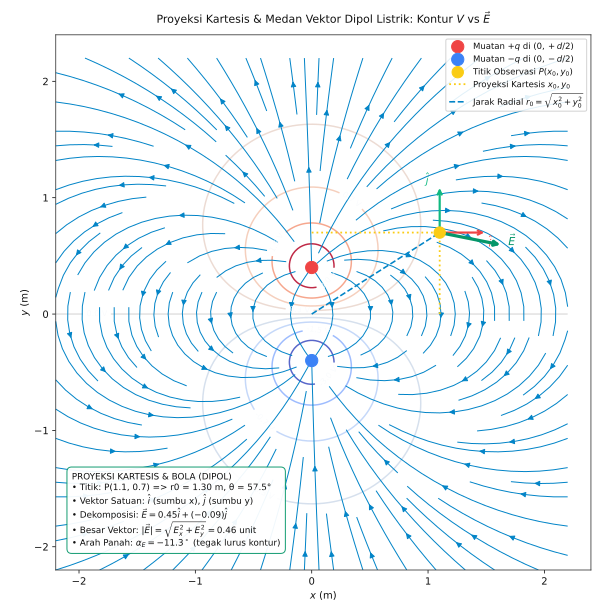

In [12]:
# Diagram Proyeksi Vektor 2D: Kontur Ekipotensial & Garis Gaya Medan Dipol (Koordinat Kartesis & Bola)
fig, ax = plt.subplots(dpi=120)

d_sep = 0.8
y_grid, x_grid = np.mgrid[-2.2:2.2:200j, -2.2:2.2:200j]

# Potensial dipol di (0, d/2) dan (0, -d/2)
r_pos = np.sqrt(x_grid**2 + (y_grid - d_sep/2)**2) + 0.05
r_neg = np.sqrt(x_grid**2 + (y_grid + d_sep/2)**2) + 0.05
V_dipole = 1.0 / r_pos - 1.0 / r_neg

levels = [-3, -1.5, -0.7, -0.3, 0.0, 0.3, 0.7, 1.5, 3]
cs = ax.contour(x_grid, y_grid, V_dipole, levels=levels, cmap='coolwarm', linewidths=1.5, alpha=0.85)
ax.clabel(cs, inline=True, fontsize=8, fmt='%1.1f V', colors='#f8fafc')

Ey, Ex = np.gradient(-V_dipole, 4.4/200, 4.4/200)
ax.streamplot(x_grid, y_grid, Ex, Ey, color='#0284c7', linewidth=1.0, density=1.2, arrowsize=1.1)

# Muatan Dipol
ax.scatter([0], [d_sep/2], color='#ef4444', s=150, zorder=6, label=r'Muatan $+q$ di $(0, +d/2)$')
ax.scatter([0], [-d_sep/2], color='#3b82f6', s=150, zorder=6, label=r'Muatan $-q$ di $(0, -d/2)$')

# Titik observasi P(x0, y0)
x0, y0 = 1.1, 0.7
r0 = np.sqrt(x0**2 + y0**2)
th0 = np.arctan2(x0, y0)

rp_p = np.sqrt(x0**2 + (y0 - d_sep/2)**2)
rm_p = np.sqrt(x0**2 + (y0 + d_sep/2)**2)
Ex_p = x0 / rp_p**3 - x0 / rm_p**3
Ey_p = (y0 - d_sep/2) / rp_p**3 - (y0 + d_sep/2) / rm_p**3
E_mag = np.hypot(Ex_p, Ey_p)
scale_E = 0.55 / E_mag
uEx, uEy = Ex_p * scale_E, Ey_p * scale_E

ax.scatter([x0], [y0], color='#facc15', s=130, zorder=8, label=r'Titik Observasi $P(x_0, y_0)$')
ax.plot([x0, x0], [0, y0], color='#facc15', ls=':', lw=1.8, label=r'Proyeksi Kartesis $x_0, y_0$')
ax.plot([0, x0], [y0, y0], color='#facc15', ls=':', lw=1.8)
ax.plot([0, x0], [0, y0], color='#0284c7', ls='--', lw=1.6, label=r'Jarak Radial $r_0 = \sqrt{x_0^2+y_0^2}$')

# Triad Vektor Satuan Kartesis di P
ax.annotate('', xy=(x0 + 0.4, y0), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", color='#ef4444', lw=2.2))
ax.text(x0 + 0.42, y0 - 0.12, r'$\hat{i}$', color='#ef4444', fontweight='bold', fontsize=10)

ax.annotate('', xy=(x0, y0 + 0.4), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", color='#10b981', lw=2.2))
ax.text(x0 - 0.12, y0 + 0.42, r'$\hat{j}$', color='#10b981', fontweight='bold', fontsize=10)

# Panah Vektor Medan Listrik E
ax.annotate('', xy=(x0 + uEx, y0 + uEy), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", color='#059669', lw=3.2))
ax.text(x0 + uEx + 0.05, y0 + uEy, r'$\vec{E}$', color='#059669', fontweight='bold', fontsize=11)

alpha_deg = np.degrees(np.arctan2(Ey_p, Ex_p))
info_dipole = (
    "PROYEKSI KARTESIS & BOLA (DIPOL)\n"
    f"• Titik: P({x0:.1f}, {y0:.1f}) => r0 = {r0:.2f} m, θ = {np.degrees(th0):.1f}°\n"
    r"• Vektor Satuan: $\hat{i}$ (sumbu x), $\hat{j}$ (sumbu y)" + "\n"
    f"• Dekomposisi: $\\vec{{E}} = {Ex_p:.2f}\\hat{{i}} + ({Ey_p:.2f})\\hat{{j}}$\n"
    f"• Besar Vektor: $|\\vec{{E}}| = \\sqrt{{E_x^2 + E_y^2}} = {E_mag:.2f}$ unit\n"
    f"• Arah Panah: $\\alpha_E = {alpha_deg:.1f}^\\circ$ (tegak lurus kontur)"
)
ax.text(0.03, 0.04, info_dipole, transform=ax.transAxes, fontsize=8.8,
        bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#059669', alpha=0.94),
        va='bottom', ha='left')

ax.set_title(r'Proyeksi Kartesis & Medan Vektor Dipol Listrik: Kontur $V$ vs $\vec{E}$',
             fontsize=11, color='#111111', pad=12)
ax.set_xlabel('$x$ (m)', fontsize=10)
ax.set_ylabel('$y$ (m)', fontsize=10)
ax.set_xlim(-2.2, 2.4)
ax.set_ylim(-2.2, 2.4)
ax.set_aspect('equal')
ax.legend(loc='upper right', framealpha=0.88, facecolor='white', edgecolor='#cccccc', fontsize=8.5)

plt.tight_layout()
plt.show()


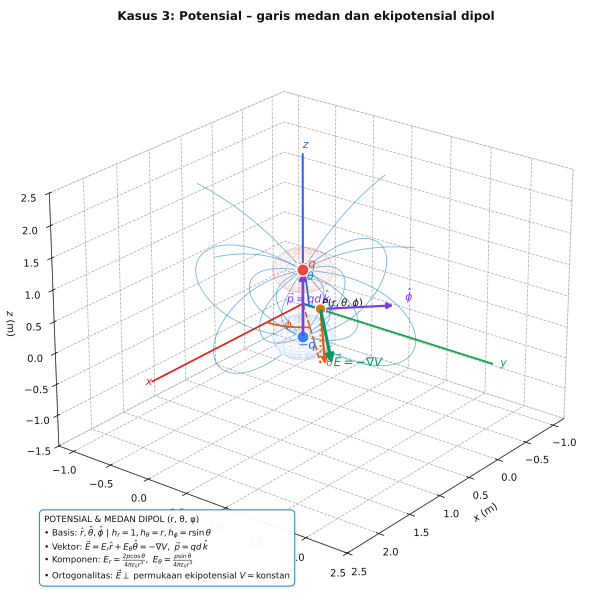

In [13]:
# Visualisasi 3D: Kasus 3: Potensial – garis medan dan ekipotensial dipol
def plot_dipole_scene(title="Proyeksi Koordinat Bola & Kartesis: Potensial & Medan Dipol Listrik 3D"):
    """Visualisasi Proyeksi 3D Potensial dan Garis Medan Dipol Listrik."""
    fig = plt.figure(dpi=120)
    ax = fig.add_subplot(111, projection='3d')
    setup_3d_pane(ax, xlim=(-1.2, 2.5), ylim=(-1.2, 2.5), zlim=(-1.5, 2.5), axis_len=2.4)
    
    d = 0.55
    p_plus = np.array([0.0, 0.0, d])
    p_minus = np.array([0.0, 0.0, -d])
    
    ax.scatter([p_plus[0]], [p_plus[1]], [p_plus[2]], color='#ef4444', s=150, zorder=20, edgecolors='white', lw=1.5)
    ax.text(p_plus[0]+0.08, p_plus[1], p_plus[2]+0.08, r'$+q$', color='#ef4444', fontweight='bold', fontsize=12)
    ax.scatter([p_minus[0]], [p_minus[1]], [p_minus[2]], color='#3b82f6', s=150, zorder=20, edgecolors='white', lw=1.5)
    ax.text(p_minus[0]+0.08, p_minus[1], p_minus[2]-0.15, r'$-q$', color='#2563eb', fontweight='bold', fontsize=12)
    
    # Vektor momen dipol p = q d z_hat
    ax.add_artist(Arrow3D([0, 0], [0, 0], [-d, d], mutation_scale=14, color='#7c3aed', arrowstyle='-|>', lw=2.8))
    ax.text(0.08, -0.15, 0.0, r'$\vec{p} = qd\,\hat{k}$', color='#7c3aed', fontweight='bold', fontsize=11)
    
    def E_dip(p):
        rp = p - p_plus; rm = p - p_minus
        dp = max(0.08, np.linalg.norm(rp)); dm = max(0.08, np.linalg.norm(rm))
        return rp / (dp**3) - rm / (dm**3)
    
    # Garis-garis medan listrik dipol
    for phi in [0, np.pi/2, np.pi, 3*np.pi/2]:
        for theta in np.linspace(0.25*np.pi, 0.75*np.pi, 4):
            p = p_plus + 0.12 * np.array([np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)])
            traj = [p.copy()]
            for _ in range(90):
                E = E_dip(p)
                Enorm = np.linalg.norm(E)
                if Enorm == 0: break
                p = p + 0.035 * E / Enorm
                traj.append(p.copy())
                if np.linalg.norm(p - p_minus) < 0.12 or np.linalg.norm(p) > 2.0: break
            traj = np.array(traj)
            if len(traj) > 4:
                ax.plot(traj[:,0], traj[:,1], traj[:,2], color='#0284c7', lw=0.9, alpha=0.55)
    
    # Permukaan ekipotensial (wireframe transparan)
    theta_eq = np.linspace(0.1, np.pi-0.1, 16)
    phi_eq = np.linspace(0, 2*np.pi, 24)
    TH, PH = np.meshgrid(theta_eq, phi_eq)
    for c_eq, z_ctr in [('#ef4444', d), ('#3b82f6', -d)]:
        req = 0.32
        ax.plot_wireframe(req*np.sin(TH)*np.cos(PH), req*np.sin(TH)*np.sin(PH), z_ctr + req*np.cos(TH),
                          color=c_eq, lw=0.35, alpha=0.22)
    
    # Titik observasi P(r, theta, phi)
    r0 = 1.7
    th0 = np.pi / 3.0
    phi0 = np.pi / 4.0
    xp = r0 * np.sin(th0) * np.cos(phi0)
    yp = r0 * np.sin(th0) * np.sin(phi0)
    zp = r0 * np.cos(th0)
    
    ax.scatter([xp], [yp], [zp], color='#d97706', s=110, zorder=15, edgecolors='white', lw=1.2)
    ax.text(xp+0.08, yp+0.08, zp+0.12, r'$P(r, \theta, \phi)$', color='#111111', fontweight='bold', fontsize=10)
    
    ax.plot([0, xp], [0, yp], [0, zp], color='#0284c7', ls='-', lw=2.0)
    ax.plot([xp, xp], [yp, yp], [0, zp], color='#d97706', ls=':', lw=2.0)
    ax.plot([0, xp], [0, yp], [0, 0], color='#ea580c', ls='--', lw=1.6)
    
    arc_th = np.linspace(0, th0, 20)
    ax.plot(0.6*np.sin(arc_th)*np.cos(phi0), 0.6*np.sin(arc_th)*np.sin(phi0), 0.6*np.cos(arc_th), color='#0284c7', lw=1.8)
    ax.text(0.7*np.sin(th0/2)*np.cos(phi0), 0.7*np.sin(th0/2)*np.sin(phi0), 0.7*np.cos(th0/2), r'$\theta$', color='#0284c7', fontweight='bold', fontsize=11)
    
    arc_phi = np.linspace(0, phi0, 20)
    ax.plot(0.6*np.cos(arc_phi), 0.6*np.sin(arc_phi), 0, color='#ea580c', lw=1.8)
    ax.text(0.7*np.cos(phi0/2), 0.7*np.sin(phi0/2), 0.04, r'$\phi$', color='#ea580c', fontweight='bold', fontsize=11)
    
    # Triad Basis Bola di P
    u_len = 0.75
    rx = np.sin(th0)*np.cos(phi0); ry = np.sin(th0)*np.sin(phi0); rz = np.cos(th0)
    tx = np.cos(th0)*np.cos(phi0); ty = np.cos(th0)*np.sin(phi0); tz = -np.sin(th0)
    px = -np.sin(phi0); py = np.cos(phi0); pz = 0.0
    
    ax.add_artist(Arrow3D([xp, xp+u_len*rx], [yp, yp+u_len*ry], [zp, zp+u_len*rz],
                          mutation_scale=12, color='#0284c7', arrowstyle='-|>', lw=2.2))
    ax.text(xp+u_len*rx+0.06, yp+u_len*ry+0.06, zp+u_len*rz+0.06, r'$\hat{r}$', color='#0284c7', fontweight='bold', fontsize=11)
    
    ax.add_artist(Arrow3D([xp, xp+u_len*tx], [yp, yp+u_len*ty], [zp, zp+u_len*tz],
                          mutation_scale=12, color='#ea580c', arrowstyle='-|>', lw=2.2))
    ax.text(xp+u_len*tx+0.06, yp+u_len*ty+0.06, zp+u_len*tz+0.06, r'$\hat{\theta}$', color='#ea580c', fontweight='bold', fontsize=11)
    
    ax.add_artist(Arrow3D([xp, xp+u_len*px], [yp, yp+u_len*py], [zp, zp+u_len*pz],
                          mutation_scale=12, color='#7c3aed', arrowstyle='-|>', lw=2.2))
    ax.text(xp+u_len*px-0.08, yp+u_len*py+0.06, zp+0.06, r'$\hat{\phi}$', color='#7c3aed', fontweight='bold', fontsize=11)
    
    # Vektor medan listrik dipol E = -grad V
    E_val = E_dip(np.array([xp, yp, zp]))
    E_dir = E_val / np.linalg.norm(E_val) * 0.95
    ax.add_artist(Arrow3D([xp, xp+E_dir[0]], [yp, yp+E_dir[1]], [zp, zp+E_dir[2]],
                          mutation_scale=16, color='#059669', arrowstyle='-|>', lw=3.2))
    ax.text(xp+E_dir[0]+0.08, yp+E_dir[1]+0.08, zp+E_dir[2]+0.06,
            r'$\vec{E} = -\nabla V$', color='#059669', fontweight='bold', fontsize=12)
    
    card_dipole = (
        "POTENSIAL & MEDAN DIPOL (r, θ, φ)\n"
        r"• Basis: $\hat{r}, \hat{\theta}, \hat{\phi}$ | $h_r=1, h_\theta=r, h_\phi=r\sin\theta$" + "\n"
        r"• Vektor: $\vec{E} = E_r\hat{r} + E_\theta\hat{\theta} = -\nabla V,\ \vec{p} = qd\,\hat{k}$" + "\n"
        r"• Komponen: $E_r = \frac{2p\cos\theta}{4\pi\epsilon_0 r^3},\ E_\theta = \frac{p\sin\theta}{4\pi\epsilon_0 r^3}$" + "\n"
        r"• Ortogonalitas: $\vec{E} \perp$ permukaan ekipotensial $V=\text{konstan}$"
    )
    ax.text2D(0.04, 0.04, card_dipole, transform=ax.transAxes, fontsize=8.6,
              bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#0284c7', alpha=0.95),
              color='#111111')
    
    ax.set_title(title, color='#111111', fontsize=12, pad=12, fontweight='bold')
    ax.view_init(elev=24, azim=38)
    plt.tight_layout()
    plt.show()
    plt.close()

plot_dipole_scene("Kasus 3: Potensial – garis medan dan ekipotensial dipol")


---
## 5. Kasus Analitik 4: Syarat Batas & Masalah Nilai Batas (Metode Keunikan dan Separasi Variabel)

**Mengapa dua teorema integral menghasilkan dua syarat batas berbeda?** Terapkan Teorema Divergensi pada pilbox tipis yang melintasi antarmuka. Ketika tinggi pilbox menuju nol, fluks sisi lengkung lenyap dan diperoleh $\hat{\mathbf n}\cdot(\mathbf E_1-\mathbf E_2)=\sigma/\epsilon_0$; untuk medan perpindahan, $D_{1n}-D_{2n}=\sigma_f$. Label sisi dan arah normal harus konsisten.
Terapkan Teorema Stokes pada loop tipis yang melintasi antarmuka. Dalam limit tinggi loop menuju nol, kontribusi sisi pendek lenyap; dari $\oint\mathbf E\cdot d\mathbf l=0$ diperoleh $\hat{\mathbf n}\times(\mathbf E_1-\mathbf E_2)=\mathbf0$. Jadi Teorema Divergensi menentukan lompatan komponen normal, sedangkan Stokes dan curl nol menentukan kontinuitas komponen tangensial. Potensial kontinu untuk muatan permukaan berhingga tanpa lapisan dipol ideal.

> **Kaitan dengan Griffiths:** Bab 2 §2.5 dan bab 3 §§3.1, 3.3 membangun syarat batas konduktor, teorema keunikan, dan separasi variabel. Data batas harus konsisten dengan persamaan sumber di dalam domain; keunikan menjamin solusi yang memenuhi seluruh data tersebut, bukan semua konfigurasi tanpa syarat.


### 5.1 Penurunan Matematis Eksak Syarat Batas Elektrostatik
Pada antarmuka dalam vakum yang memuat rapat muatan permukaan total $\sigma$, syarat batas elektrostatik diperoleh dari persamaan Maxwell. Dengan normal $\hat{\mathbf{n}}$ diarahkan dari sisi 2 ke sisi 1:
1. **Diskontinuitas Komponen Normal (dari Hukum Gauss):**
   Dengan membangun pilbox Gaussian silindris infinitesimal melintasi batas berorientasi normal $\hat{\mathbf{n}}$ dari medium 2 ke medium 1:
   $$\oint \mathbf{E} \cdot d\mathbf{a} = (E_1^\perp - E_2^\perp) A = \frac{\sigma A}{\epsilon_0} \implies E_1^\perp - E_2^\perp = \frac{\sigma}{\epsilon_0}$$
   Dalam representasi potensial skalar ($E^\perp = -\partial V/\partial n$):
   $$\left. \frac{\partial V_1}{\partial n} \right|_{\text{batas}} - \left. \frac{\partial V_2}{\partial n} \right|_{\text{batas}} = -\frac{\sigma}{\epsilon_0}$$
2. **Kontinuitas Komponen Tangensial (dari $\nabla \times \mathbf{E} = \mathbf{0}$):**
   Dengan membangun loop integrasi persegi panjang tipis menyusuri permukaan antarmuka:
   $$\oint \mathbf{E} \cdot d\mathbf{l} = (E_1^\parallel - E_2^\parallel) L = 0 \implies E_1^\parallel - E_2^\parallel = 0$$
   Untuk rapat muatan permukaan berhingga (tanpa lapisan dipol ideal), potensial kontinu melintasi antarmuka:
   $V_1(\mathbf{r}_{\text{batas}}) = V_2(\mathbf{r}_{\text{batas}})$
3. **Syarat Batas pada Konduktor Ideal:**
   Di dalam konduktor statis, muatan bebas terdistribusi sedemikian hingga $\mathbf{E} = \mathbf{0}$ di seluruh volume konduktor (*equipotential volume*). Akibatnya, medan listrik tepat di luar permukaan konduktor harus selalu tegak lurus sempurna terhadap permukaan:
   $$\mathbf{E} = \frac{\sigma}{\epsilon_0} \hat{\mathbf{n}}, \quad E^\parallel = 0$$

### 5.2 Metode Keunikan (Uniqueness Theorems)
Ketika menyelesaikan Persamaan Laplace $\nabla^2 V = 0$ dalam suatu domain dengan syarat batas tertentu, bagaimana kita yakin bahwa solusi yang kita temukan adalah satu-satunya solusi yang benar? Pertanyaan mendasar ini dijawab secara pasti oleh **Teorema Keunikan**:

#### Teorema Keunikan Pertama (First Uniqueness Theorem - Syarat Batas Dirichlet)
> **Teorema Dirichlet:** Jika rapat muatan di dalam domain ditetapkan, solusi Persamaan Poisson (termasuk Laplace saat $\rho=0$) ditentukan secara unik oleh nilai potensial pada seluruh batas domain.

**Pembuktian Matematis Eksak (Identitas Green):**
Andaikan terdapat dua solusi potensial berbeda, $V_1(\mathbf{r})$ dan $V_2(\mathbf{r})$, yang sama-sama memenuhi persamaan Laplace di dalam $\mathcal{V}$ dan memenuhi syarat batas Dirichlet yang identik pada seluruh permukaan $\mathcal{S}$:
$$\nabla^2 V_1 = 0, \quad \nabla^2 V_2 = 0 \quad (\text{di dalam } \mathcal{V})$$
$$V_1 = V_2 = V_b \quad (\text{pada permukaan batas } \mathcal{S})$$

Definisikan fungsi selisih potensial:
$$V_d(\mathbf{r}) \equiv V_1(\mathbf{r}) - V_2(\mathbf{r})$$
Karena persamaan Laplace bersifat linear, $V_d$ memenuhi:
$$\nabla^2 V_d = \nabla^2 V_1 - \nabla^2 V_2 = 0 \quad (\text{di dalam } \mathcal{V})$$
$$V_d(\mathbf{r}) = V_1 - V_2 = 0 \quad (\text{pada permukaan batas } \mathcal{S})$$

Tinjau divergensi dari medan vektor $V_d \nabla V_d$ dengan menggunakan aturan rantai diferensial:
$$\nabla \cdot (V_d \nabla V_d) = (\nabla V_d) \cdot (\nabla V_d) + V_d (\nabla^2 V_d) = (\nabla V_d)^2 + 0 = (\nabla V_d)^2$$

Integrasikan identitas ini ke seluruh volume $\mathcal{V}$ dan terapkan Teorema Divergensi Gauss:
$$\int_{\mathcal{V}} (\nabla V_d)^2 d\tau = \int_{\mathcal{V}} \nabla \cdot (V_d \nabla V_d) d\tau = \oint_{\mathcal{S}} V_d \nabla V_d \cdot d\mathbf{a}$$

Karena pada seluruh permukaan batas $\mathcal{S}$ nilai $V_d = 0$, maka integral permukaan di ruas kanan identik lenyap:
$$\int_{\mathcal{V}} (\nabla V_d)^2 d\tau = 0$$

Perhatikan bahwa integran $(\nabla V_d)^2 = |\nabla V_d|^2 \ge 0$ bernilai kuadratik riil (non-negatif di setiap titik di dalam $\mathcal{V}$). Satu-satunya cara integral volume dari fungsi non-negatif menghasilkan nilai tepat nol adalah jika integrannya nol di seluruh titik:
$$\nabla V_d = \mathbf{0} \quad \text{di setiap titik dalam } \mathcal{V}$$

Gradien yang lenyap mengimplikasikan bahwa $V_d(\mathbf{r}) = \text{konstan}$. Karena $V_d = 0$ pada permukaan batas $\mathcal{S}$, maka konstanta tersebut haruslah nol:
$$V_d(\mathbf{r}) = 0 \implies V_1(\mathbf{r}) = V_2(\mathbf{r}) \quad \forall \mathbf{r} \in \mathcal{V}$$
**Q.E.D.** Solusi persamaan Laplace terbukti tunggal dan unik!

#### Teorema Keunikan Kedua (Second Uniqueness Theorem - Syarat Batas Neumann)
Jika rapat muatan di ruang dan muatan total setiap konduktor ditentukan, medan listrik ditentukan secara unik. Untuk data Neumann murni, potensial tetap bebas terhadap penambahan konstanta; medan listriknya tetap unik.

### 5.3 Metode Separasi Variabel pada Persamaan Laplace
Metode Separasi Variabel (*Separation of Variables*) merupakan teknik analitik paling berdaya guna untuk menyelesaikan persamaan diferensial parsial eliptik Laplace.

Tinjau Persamaan Laplace 2-Dimensi dalam koordinat Kartesian:
$$\nabla^2 V = \frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} = 0$$

Asumsikan solusi berbentuk perkalian dua fungsi variabel terpisah (*ansatz product*):
$$V(x, y) = X(x) Y(y)$$
Substitusi ke dalam persamaan Laplace dan bagi kedua ruas dengan $X(x)Y(y)$:
$$\frac{1}{X(x)} \frac{d^2 X}{dx^2} + \frac{1}{Y(y)} \frac{d^2 Y}{dy^2} = 0 \iff \frac{1}{X} \frac{d^2 X}{dx^2} = -\frac{1}{Y} \frac{d^2 Y}{dy^2}$$

Ruas kiri hanya bergantung pada $x$, sedangkan ruas kanan hanya bergantung pada $y$. Kedua ruas hanya bisa sama jika keduanya sama dengan konstanta pemisah (*separation constant*) $-k^2$:
$$\frac{d^2 X}{dx^2} + k^2 X = 0 \implies X(x) = A\cos(kx) + B\sin(kx)$$
$$\frac{d^2 Y}{dy^2} - k^2 Y = 0 \implies Y(y) = C\cosh(ky) + D\sinh(ky)$$

#### Studi Kasus Analitik: Saluran Konduktor Persegi Panjang Tak Hingga (Rectangular Waveguide Conduit)
Tinjau domain persegi panjang berukuran $a\times b$ (uniform sepanjang arah $z$). Dinding samping ($x=0$, $x=a$) dan bawah ($y=0$) di-ground ($V=0$), sedangkan sisi atas ($y=b$) dijaga pada potensial $V_0$:
1. $V(0, y) = 0 \implies A = 0 \implies X(x) = B\sin(kx)$
2. $V(a, y) = 0 \implies \sin(ka) = 0 \implies k_n = \frac{n\pi}{a} \quad (n = 1, 2, 3, \dots)$
3. $V(x, 0) = 0 \implies C = 0 \implies Y(y) = D\sinh\left(\frac{n\pi y}{a}\right)$

Solusi moda individual untuk setiap bilangan bulat $n$ adalah:
$$V_n(x, y) = C_n \sin\left(\frac{n\pi x}{a}\right) \sinh\left(\frac{n\pi y}{a}\right)$$

### 5.4 Formulasi Persamaan Superposisi pada Syarat Batas, Metode Keunikan, dan Separasi
1. **Superposisi Linear Moda Ortogonal Fourier:**
   Karena persamaan Laplace linear, kombinasi linear tak hingga (*superposisi*) dari seluruh moda $V_n$ otomatis merupakan solusi dari persamaan Laplace:
   $$V(x, y) = \sum_{n=1}^\infty C_n \sin\left(\frac{n\pi x}{a}\right) \sinh\left(\frac{n\pi y}{a}\right)$$
   Pada batas atas ($y = b$), syarat batas $V(x, b) = V_0$ harus dipenuhi:
   $$V_0 = \sum_{n=1}^\infty \left[ C_n \sinh\left(\frac{n\pi b}{a}\right) \right] \sin\left(\frac{n\pi x}{a}\right)$$
   Memanfaatkan ortogonalitas basis Fourier $\int_0^a \sin\left(\frac{n\pi x}{a}\right)\sin\left(\frac{m\pi x}{a}\right) dx = \frac{a}{2}\delta_{nm}$:
   $$C_n \sinh\left(\frac{n\pi b}{a}\right) = \frac{2}{a} \int_0^a V_0 \sin\left(\frac{n\pi x}{a}\right) dx = \frac{2V_0}{n\pi} (1 - (-1)^n)$$
   Koefisien hanya eksis untuk $n$ ganjil ($n = 1, 3, 5, \dots$):
   $$C_n = \frac{4V_0}{n\pi \sinh(n\pi b/a)}$$
   Solusi analitik eksak deret superposisi Laplace:
   $$V(x, y) = \frac{4V_0}{\pi} \sum_{n=1,3,5,\dots}^\infty \frac{1}{n} \sin\left(\frac{n\pi x}{a}\right) \frac{\sinh(n\pi y/a)}{\sinh(n\pi b/a)}$$

2. **Peran Teorema Keunikan:**
   Teorema keunikan menjamin bahwa deret Fourier yang memenuhi persamaan Laplace dan seluruh kondisi batas di atas adalah solusi potensial tunggal untuk domain tersebut.

3. **Prinsip Dekomposisi Superposisi Batas Multi-Potensial:**
   Jika sebuah saluran memiliki potensial yang berbeda di keempat dindingnya: $V_{\text{top}}(x)$, $V_{\text{bot}}(x)$, $V_{\text{left}}(y)$, dan $V_{\text{right}}(y)$, kita tidak perlu menyelesaikan sistem coupled yang rumit. Berdasarkan prinsip superposisi:
   $$V_{\text{total}}(x, y) = V^{(1)}(x, y) + V^{(2)}(x, y) + V^{(3)}(x, y) + V^{(4)}(x, y)$$
   di mana masing-masing $V^{(k)}$ diselesaikan secara terpisah dengan hanya satu dinding berpotensial tak nol dan tiga dinding lainnya grounded ($V=0$).


In [14]:
# Verifikasi Simbolik SymPy: Separasi Variabel Persamaan Laplace pada Saluran Konduktor
x_s, y_s, a_s, b_s, V0_s = sp.symbols('x y a b V_0', positive=True, real=True)
n_sym = sp.symbols('n', integer=True, positive=True)

# 1. Definisi k_n dan koefisien Fourier C_n
k_n = n_sym * sp.pi / a_s
# C_n untuk n ganjil
C_n_sym = 4 * V0_s / (n_sym * sp.pi * sp.sinh(n_sym * sp.pi * b_s / a_s))

# 2. Moda potensial ke-n
V_n = C_n_sym * sp.sin(k_n * x_s) * sp.sinh(k_n * y_s)

# 3. Verifikasi Identitas Persamaan Laplace: d2V/dx2 + d2V/dy2 == 0
laplacian_V_n = sp.diff(V_n, x_s, 2) + sp.diff(V_n, y_s, 2)
laplacian_simplified = sp.simplify(laplacian_V_n)

# 4. Verifikasi Syarat Batas Dirichlet pada Batas Grounded
V_at_x0 = V_n.subs(x_s, 0)
V_at_xa = sp.simplify(V_n.subs(x_s, a_s))  # sin(n*pi) = 0
V_at_y0 = V_n.subs(y_s, 0)                 # sinh(0) = 0

print("=== VERIFIKASI SIMBOLIK SYMPY: SEPARASI VARIABEL PERSAMAAN LAPLACE ===")
print(f"Moda Potensial V_n(x, y) = {V_n}")
print(f"Laplacian [d²V_n/dx² + d²V_n/dy²] = {laplacian_simplified} (Persamaan Laplace Terbukti Eksak 0)")
print(f"Syarat Batas Dirichlet pada x = 0 : V_n(0, y) = {V_at_x0}")
print(f"Syarat Batas Dirichlet pada x = a : V_n(a, y) = {V_at_xa}")
print(f"Syarat Batas Dirichlet pada y = 0 : V_n(x, 0) = {V_at_y0}")

# 5. Uji Konvergensi Superposisi Fourier pada Batas Atas y = b
a_num, b_num, V0_num = 1.0, 1.0, 100.0
x_mid = 0.5 * a_num
terms = [float((4.0 * V0_num / (n * np.pi)) * np.sin(n * np.pi * x_mid / a_num)) for n in range(1, 41, 2)]
print(f"\nUji Konvergensi Superposisi Deret Fourier di Tengah Batas Atas (x = a/2, y = b):")
for n_idx, n_val in enumerate([1, 3, 5, 9, 21, 35]):
    sum_val = sum(terms[:n_idx+1])
    print(f"  Jumlah hingga n = {n_val:2d}: V = {sum_val:.2f} V (Target Analitik V₀ = {V0_num:.2f} V)")


=== VERIFIKASI SIMBOLIK SYMPY: SEPARASI VARIABEL PERSAMAAN LAPLACE ===
Moda Potensial V_n(x, y) = 4*V_0*sin(pi*n*x/a)*sinh(pi*n*y/a)/(pi*n*sinh(pi*b*n/a))
Laplacian [d²V_n/dx² + d²V_n/dy²] = 0 (Persamaan Laplace Terbukti Eksak 0)
Syarat Batas Dirichlet pada x = 0 : V_n(0, y) = 0
Syarat Batas Dirichlet pada x = a : V_n(a, y) = 0
Syarat Batas Dirichlet pada y = 0 : V_n(x, 0) = 0

Uji Konvergensi Superposisi Deret Fourier di Tengah Batas Atas (x = a/2, y = b):
  Jumlah hingga n =  1: V = 127.32 V (Target Analitik V₀ = 100.00 V)
  Jumlah hingga n =  3: V = 84.88 V (Target Analitik V₀ = 100.00 V)
  Jumlah hingga n =  5: V = 110.35 V (Target Analitik V₀ = 100.00 V)
  Jumlah hingga n =  9: V = 92.16 V (Target Analitik V₀ = 100.00 V)
  Jumlah hingga n = 21: V = 106.31 V (Target Analitik V₀ = 100.00 V)
  Jumlah hingga n = 35: V = 94.73 V (Target Analitik V₀ = 100.00 V)


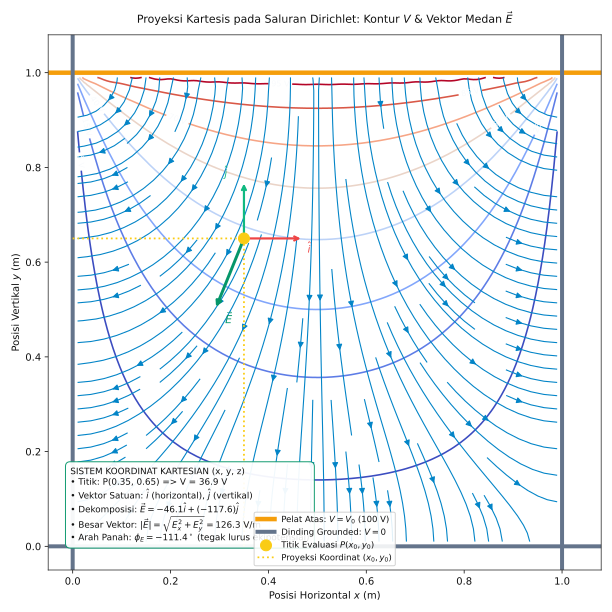

In [15]:
# Diagram Proyeksi Vektor 2D: Saluran Konduktor Persegi Panjang (Koordinat Kartesis)
fig, ax = plt.subplots(dpi=120)

a_val, b_val, V0_val = 1.0, 1.0, 100.0

x_grid = np.linspace(0.01, a_val - 0.01, 150)
y_grid = np.linspace(0.01, b_val - 0.01, 150)
X_m, Y_m = np.meshgrid(x_grid, y_grid)

V_2d = np.zeros_like(X_m)
Ex_2d = np.zeros_like(X_m)
Ey_2d = np.zeros_like(X_m)

for n in range(1, 41, 2):
    kn = n * np.pi / a_val
    cn = (4.0 * V0_val) / (n * np.pi * np.sinh(kn * b_val))
    V_2d += cn * np.sin(kn * X_m) * np.sinh(kn * Y_m)
    Ex_2d -= cn * kn * np.cos(kn * X_m) * np.sinh(kn * Y_m)
    Ey_2d -= cn * kn * np.sin(kn * X_m) * np.cosh(kn * Y_m)

levels = [5, 15, 25, 40, 55, 70, 85, 95]
cs = ax.contour(X_m, Y_m, V_2d, levels=levels, cmap='coolwarm', linewidths=1.6)
ax.clabel(cs, inline=True, fontsize=8, fmt='%1.0f V', colors='#f8fafc')

ax.streamplot(x_grid, y_grid, Ex_2d, Ey_2d, color='#0284c7', linewidth=1.1, density=1.2, arrowsize=1.2)

ax.axhline(y=b_val, color='#f59e0b', linewidth=4.5, label=r'Pelat Atas: $V=V_0$ ($100\text{ V}$)')
ax.axhline(y=0, color='#64748b', linewidth=4.0, label=r'Dinding Grounded: $V=0$')
ax.axvline(x=0, color='#64748b', linewidth=4.0)
ax.axvline(x=a_val, color='#64748b', linewidth=4.0)

# Titik evaluasi tertentu P(x0, y0)
x0, y0 = 0.35, 0.65
V_p, Ex_p, Ey_p = 0, 0, 0
for n in range(1, 41, 2):
    kn = n * np.pi / a_val
    cn = (4.0 * V0_val) / (n * np.pi * np.sinh(kn * b_val))
    V_p += cn * np.sin(kn * x0) * np.sinh(kn * y0)
    Ex_p -= cn * kn * np.cos(kn * x0) * np.sinh(kn * y0)
    Ey_p -= cn * kn * np.sin(kn * x0) * np.cosh(kn * y0)
E_mag = np.hypot(Ex_p, Ey_p)
scale_E = 0.16 / E_mag
uEx, uEy = Ex_p * scale_E, Ey_p * scale_E

ax.scatter([x0], [y0], color='#facc15', s=120, zorder=8, label=r'Titik Evaluasi $P(x_0, y_0)$')
ax.plot([x0, x0], [0, y0], color='#facc15', ls=':', lw=1.8, label=r'Proyeksi Koordinat $(x_0, y_0)$')
ax.plot([0, x0], [y0, y0], color='#facc15', ls=':', lw=1.8)

# Triad Vektor Satuan Kartesis
ax.annotate('', xy=(x0 + 0.12, y0), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", color='#ef4444', lw=2.2))
ax.text(x0 + 0.13, y0 - 0.03, r'$\hat{i}$', color='#ef4444', fontweight='bold', fontsize=10)

ax.annotate('', xy=(x0, y0 + 0.12), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", color='#10b981', lw=2.2))
ax.text(x0 - 0.04, y0 + 0.13, r'$\hat{j}$', color='#10b981', fontweight='bold', fontsize=10)

# Panah Vektor Medan Listrik E
ax.annotate('', xy=(x0 + uEx, y0 + uEy), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", color='#059669', lw=3.0))
ax.text(x0 + uEx + 0.02, y0 + uEy - 0.03, r'$\vec{E}$', color='#059669', fontweight='bold', fontsize=11)

alpha_E = np.degrees(np.arctan2(Ey_p, Ex_p))
info_channel = (
    "SISTEM KOORDINAT KARTESIAN (x, y, z)\n"
    f"• Titik: P({x0:.2f}, {y0:.2f}) => V = {V_p:.1f} V\n"
    r"• Vektor Satuan: $\hat{i}$ (horizontal), $\hat{j}$ (vertikal)" + "\n"
    f"• Dekomposisi: $\\vec{{E}} = {Ex_p:.1f}\\hat{{i}} + ({Ey_p:.1f})\\hat{{j}}$\n"
    f"• Besar Vektor: $|\\vec{{E}}| = \\sqrt{{E_x^2 + E_y^2}} = {E_mag:.1f}$ V/m\n"
    f"• Arah Panah: $\\phi_E = {alpha_E:.1f}^\\circ$ (tegak lurus ekipotensial)"
)
ax.text(0.04, 0.05, info_channel, transform=ax.transAxes, fontsize=8.8,
        bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#059669', alpha=0.94),
        va='bottom', ha='left')

ax.set_title(r'Proyeksi Kartesis pada Saluran Dirichlet: Kontur $V$ & Vektor Medan $\vec{E}$',
             fontsize=11, color='#111111', pad=12)
ax.set_xlabel('Posisi Horizontal $x$ (m)', fontsize=10)
ax.set_ylabel('Posisi Vertikal $y$ (m)', fontsize=10)
ax.set_xlim(-0.05, a_val + 0.08)
ax.set_ylim(-0.05, b_val + 0.08)
ax.legend(loc='lower center', framealpha=0.88, facecolor='white', edgecolor='#cccccc', fontsize=8.5)

plt.tight_layout()
plt.show()


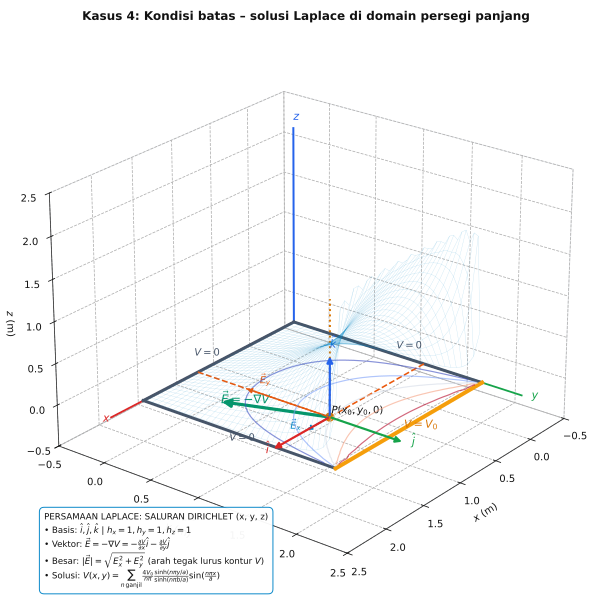

In [16]:
# Visualisasi 3D: Kasus 4: Kondisi batas – solusi Laplace di domain persegi panjang
def plot_channel_scene(title="Proyeksi Koordinat Kartesian: Persamaan Laplace Saluran Konduktor 3D"):
    """Visualisasi Proyeksi 3D Persamaan Laplace pada Saluran Dirichlet (Koordinat Kartesian)."""
    fig = plt.figure(dpi=120)
    ax = fig.add_subplot(111, projection='3d')
    setup_3d_pane(ax, xlim=(-0.5, 2.5), ylim=(-0.5, 2.5), zlim=(-0.5, 2.5), axis_len=2.4)
    
    a, b = 2.0, 2.0
    V0 = 100.0
    
    # Batas-batas saluran konduktor Dirichlet
    ax.plot([0, a], [0, 0], [0, 0], color='#475569', lw=3.0, label='Grounded (V=0)')
    ax.plot([0, 0], [0, b], [0, 0], color='#475569', lw=3.0)
    ax.plot([a, a], [0, b], [0, 0], color='#475569', lw=3.0)
    ax.plot([0, a], [b, b], [0, 0], color='#f59e0b', lw=4.0, label='Pelat Atas (V=V0)')
    ax.text(a/2, b+0.1, 0, r'$V = V_0$', color='#d97706', fontweight='bold', fontsize=11, ha='center')
    ax.text(a/2, -0.15, 0, r'$V = 0$', color='#475569', fontweight='bold', fontsize=10, ha='center')
    ax.text(-0.15, b/2, 0, r'$V = 0$', color='#475569', fontweight='bold', fontsize=10, va='center')
    ax.text(a+0.1, b/2, 0, r'$V = 0$', color='#475569', fontweight='bold', fontsize=10, va='center')
    
    # Kontur ekipotensial dalam saluran
    xc = np.linspace(0.02, a-0.02, 35)
    yc = np.linspace(0.02, b-0.02, 35)
    XC, YC = np.meshgrid(xc, yc)
    V_grid = np.zeros_like(XC)
    for n in range(1, 22, 2):
        k = n * np.pi / a
        V_grid += (4.0 * V0 / (n * np.pi)) * np.sin(k * XC) * np.sinh(k * YC) / np.sinh(k * b)
    
    # Plot kontur ekipotensial pada bidang z = 0
    levels = [10, 25, 45, 65, 85]
    cs = ax.contour(XC, YC, V_grid, levels=levels, cmap='coolwarm', alpha=0.6, zdir='z', offset=0, linewidths=1.2)
    
    # Wireframe permukaan potensial 3D (diskalakan agar masuk range z)
    V_scale = 2.0 / V0
    ax.plot_wireframe(XC, YC, V_grid * V_scale, color='#0284c7', lw=0.35, alpha=0.22)
    
    # Titik Evaluasi P(x0, y0, z0)
    x0, y0 = 1.3, 1.4
    z0 = 0.0
    ax.scatter([x0], [y0], [z0], color='#d97706', s=110, zorder=15, edgecolors='white', lw=1.2)
    ax.text(x0+0.08, y0+0.08, z0+0.12, r'$P(x_0, y_0, 0)$', color='#111111', fontweight='bold', fontsize=10)
    
    # Proyeksi Kartesis
    ax.plot([x0, x0], [0, y0], [0, 0], color='#ea580c', ls='--', lw=1.6)
    ax.plot([0, x0], [y0, y0], [0, 0], color='#ea580c', ls='--', lw=1.6)
    ax.plot([x0, x0], [y0, y0], [0, 1.4], color='#d97706', ls=':', lw=2.0)
    
    # Triad Basis Kartesian di P
    u_len = 0.75
    ax.add_artist(Arrow3D([x0, x0+u_len], [y0, y0], [z0, z0],
                          mutation_scale=12, color='#dc2626', arrowstyle='-|>', lw=2.2))
    ax.text(x0+u_len+0.08, y0, z0, r'$\hat{i}$', color='#dc2626', fontweight='bold', fontsize=11)
    
    ax.add_artist(Arrow3D([x0, x0], [y0, y0+u_len], [z0, z0],
                          mutation_scale=12, color='#16a34a', arrowstyle='-|>', lw=2.2))
    ax.text(x0, y0+u_len+0.08, z0, r'$\hat{j}$', color='#16a34a', fontweight='bold', fontsize=11)
    
    ax.add_artist(Arrow3D([x0, x0], [y0, y0], [z0, z0+u_len],
                          mutation_scale=12, color='#2563eb', arrowstyle='-|>', lw=2.2))
    ax.text(x0, y0, z0+u_len+0.08, r'$\hat{k}$', color='#2563eb', fontweight='bold', fontsize=11)
    
    # Hitung gradien E = -grad V di P
    eps = 0.01
    def v_pt(x, y):
        val = 0.0
        for n in range(1, 26, 2):
            k = n * np.pi / a
            val += (4.0 * V0 / (n * np.pi)) * np.sin(k * x) * np.sinh(k * y) / np.sinh(k * b)
        return val
    
    Ex = -(v_pt(x0+eps, y0) - v_pt(x0-eps, y0)) / (2*eps)
    Ey = -(v_pt(x0, y0+eps) - v_pt(x0, y0-eps)) / (2*eps)
    Emag = np.hypot(Ex, Ey)
    scale_E = 0.95 / Emag
    uEx, uEy = Ex * scale_E, Ey * scale_E
    
    # Vektor resultan medan listrik E = -grad V
    ax.add_artist(Arrow3D([x0, x0+uEx], [y0, y0+uEy], [z0, z0],
                          mutation_scale=16, color='#059669', arrowstyle='-|>', lw=3.2))
    ax.text(x0+uEx+0.08, y0+uEy+0.08, z0+0.05,
            r'$\vec{E} = -\nabla V$', color='#059669', fontweight='bold', fontsize=12)
    
    # Komponen Ex dan Ey
    ax.add_artist(Arrow3D([x0, x0+uEx], [y0, y0], [z0, z0],
                          mutation_scale=10, color='#0284c7', arrowstyle='-|>', lw=1.6, ls='--'))
    ax.text(x0+uEx+0.04, y0-0.12, z0, r'$\vec{E}_x$', color='#0284c7', fontsize=9.5)
    ax.add_artist(Arrow3D([x0, x0], [y0, y0+uEy], [z0, z0],
                          mutation_scale=10, color='#ea580c', arrowstyle='-|>', lw=1.6, ls='--'))
    ax.text(x0-0.15, y0+uEy+0.04, z0, r'$\vec{E}_y$', color='#ea580c', fontsize=9.5)
    
    card_channel = (
        "PERSAMAAN LAPLACE: SALURAN DIRICHLET (x, y, z)\n"
        r"• Basis: $\hat{i}, \hat{j}, \hat{k}$ | $h_x=1, h_y=1, h_z=1$" + "\n"
        r"• Vektor: $\vec{E} = -\nabla V = -\frac{\partial V}{\partial x}\hat{i} - \frac{\partial V}{\partial y}\hat{j}$" + "\n"
        r"• Besar: $|\vec{E}| = \sqrt{E_x^2 + E_y^2}$ (arah tegak lurus kontur $V$)" + "\n"
        r"• Solusi: $V(x,y) = \sum_{n\,\mathrm{ganjil}} \frac{4V_0}{n\pi}\frac{\sinh(n\pi y/a)}{\sinh(n\pi b/a)}\sin(\frac{n\pi x}{a})$"
    )
    ax.text2D(0.04, 0.04, card_channel, transform=ax.transAxes, fontsize=8.6,
              bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#0284c7', alpha=0.95),
              color='#111111')
    
    ax.set_title(title, color='#111111', fontsize=12, pad=12, fontweight='bold')
    ax.view_init(elev=24, azim=38)
    plt.tight_layout()
    plt.show()
    plt.close()

plot_channel_scene("Kasus 4: Kondisi batas – solusi Laplace di domain persegi panjang")


---
## 6. Kasus Analitik 5: Bahan Dielektrik, Polarisasi, dan Kapasitansi

**Hubungan divergensi dan curl pada bahan dielektrik.** Dari $\rho_b=-\nabla\cdot\mathbf P$ dan Hukum Gauss total, $\nabla\cdot\mathbf E=(\rho_f+\rho_b)/\epsilon_0$. Dengan $\mathbf D=\epsilon_0\mathbf E+\mathbf P$, suku divergensi polarisasi tereliminasi dan tersisa $\nabla\cdot\mathbf D=\rho_f$. Teorema Divergensi memberi $\oint\mathbf D\cdot d\mathbf a=Q_{f,\rm enc}$: fluks $\mathbf D$ menghitung muatan bebas yang dilingkupi.
Curl medan listrik tetap $\nabla\times\mathbf E=0$ dalam elektrostatika, sehingga beda potensial bebas lintasan. Namun, umumnya $\nabla\times\mathbf D=\nabla\times\mathbf P$ dan tidak harus nol. Pada antarmuka dielektrik, komponen normal $\mathbf D$ melompat sebesar rapat muatan bebas permukaan, sedangkan komponen tangensial $\mathbf E$ kontinu. Relasi $\mathbf D=\epsilon\mathbf E$ berlaku untuk bahan linear, isotropik, dan homogen.

> **Kaitan dengan Griffiths:** Bab 4 §§4.1–4.4 memisahkan muatan bebas dari muatan terikat. $\mathbf{P}$ merangkum momen dipol per volume; $\mathbf{D}=\epsilon_0\mathbf{E}+\mathbf{P}$ dipilih agar $\nabla\cdot\mathbf{D}=\rho_f$. Hubungan $\mathbf{D}=\epsilon\mathbf{E}$ memerlukan model bahan linear, isotropik, dan homogen.


### 6.1 Penurunan Matematis Eksak
Ketika medan listrik $\mathbf{E}$ diterapkan pada material isolator (dielektrik), dipol-dipol mikroskopis mengalami pergeseran yang menghasilkan **Vektor Polarisasi** $\mathbf{P} = d\mathbf{p}/d\tau$. Polarisasi memunculkan **muatan terikat** (*bound charges*):
$$\rho_b = -\nabla \cdot \mathbf{P}, \quad \sigma_b = \mathbf{P} \cdot \hat{\mathbf{n}}$$

Vektor pergeseran listrik didefinisikan secara umum sebagai:
$\mathbf{D} \equiv \epsilon_0 \mathbf{E} + \mathbf{P}, \qquad \nabla \cdot \mathbf{D} = \rho_f, \qquad \oint_{\mathcal{S}} \mathbf{D} \cdot d\mathbf{a} = Q_{f,\text{enc}}$
Untuk dielektrik linear, isotropik, dan homogen, $\mathbf{P}=\epsilon_0\chi_e\mathbf{E}$ sehingga $\mathbf{D}=\epsilon\mathbf{E}=\epsilon_r\epsilon_0\mathbf{E}$.

#### Sistem Kapasitor Silinder Koaksial dengan Lapisan Dielektrik
Kapasitansi silinder koaksial berpanjang $L$, radius dalam $a$, radius luar $b$, dan permitivitas relatif $\epsilon_r$:
$$C = \frac{2\pi \epsilon_r \epsilon_0 L}{\ln(b/a)}$$
Energi yang tersimpan di dalam kapasitor:
$$U = \frac{1}{2} C (\Delta V)^2 = \frac{1}{2} \int \mathbf{D} \cdot \mathbf{E} d\tau = \frac{\pi \epsilon_r \epsilon_0 L (\Delta V)^2}{\ln(b/a)}$$

### 6.2 Penjelasan Fisis Muatan Terikat (*Bound Charges*)
Pada batas dielektrik di $s = a$, muatan terikat negatif $\sigma_b(a) = -\frac{\epsilon_r - 1}{\epsilon_r} \frac{\lambda_f}{2\pi a}$ sebagian menetralkan muatan bebas positif $+Q$ pada konduktor dalam, sehingga melemahkan medan listrik $\mathbf{E}$ di dalam rongga dan menurunkan beda potensial $\Delta V$. Akibatnya, kapasitas penyimpanan muatan ($C = Q/\Delta V$) meningkat pesat.

### 6.3 Formulasi Persamaan Superposisi: Polarisasi Makroskopis & Kapasitor Majemuk
1. **Superposisi Medan di Dalam Bahan Dielektrik:**
   Medan listrik total $\mathbf{E}$ di setiap titik di dalam bahan dielektrik merupakan **superposisi vektor** antara medan luar yang bersumber dari muatan bebas $\mathbf{E}_0$ dan medan polarisasi $\mathbf{E}_{\text{pol}}$ yang bersumber dari muatan terikat:
   $$\mathbf{E}(\mathbf{r}) = \mathbf{E}_0(\mathbf{r}) + \mathbf{E}_{\text{pol}}(\mathbf{r})$$
   Pada kapasitor bergeometri tetap dengan muatan bebas yang dipertahankan, polarisasi dielektrik linear mengurangi medan dibandingkan kasus vakum:
   $\mathbf{E}(\mathbf{r}) = \mathbf{E}_0(\mathbf{r}) - \frac{\mathbf{P}(\mathbf{r})}{\epsilon_0} = \frac{\mathbf{E}_0(\mathbf{r})}{\epsilon_r}$
Hubungan sederhana ini tidak berlaku universal untuk setiap geometri atau kondisi sumber.

2. **Superposisi Volume Momen Dipol Molekuler:**
   Secara mikroskopis, polarisasi adalah rata-rata momen dipol dalam elemen volume mesoskala (cukup kecil dibanding skala makroskopis, tetapi masih memuat banyak molekul):
   $\mathbf{P}(\mathbf{r}) \simeq \frac{1}{\Delta \tau} \sum_{i \in \Delta \tau} \mathbf{p}_i = n\langle\mathbf{p}\rangle$

3. **Superposisi Beda Potensial pada Kapasitansi Majemuk (Dielektrik Berlapis Seri):**
   Jika ruang antar-elektroda diisi oleh $N$ lapisan dielektrik konsentris berbeda dengan konstanta $\epsilon_{r1}, \epsilon_{r2}, \dots$, berdasarkan sifat integral garis potensial, beda potensial total antar-pelat adalah **superposisi linear dari beda potensial masing-masing lapisan**:
   $$\Delta V_{\text{total}} = \sum_{k=1}^N \Delta V_k = \sum_{k=1}^N \int_{s_k}^{s_{k+1}} \frac{\lambda_f}{2\pi \epsilon_{rk} \epsilon_0 s} ds = \frac{\lambda_f}{2\pi\epsilon_0} \sum_{k=1}^N \frac{1}{\epsilon_{rk}} \ln\left(\frac{s_{k+1}}{s_k}\right)$$
   Karena muatan bebas yang dilingkupi bernilai sama untuk setiap lapisan, superposisi beda potensial ini secara langsung menurunkan hukum superposisi kebalikan kapasitansi seri:
   $$\frac{1}{C_{\text{total}}} = \frac{\Delta V_{\text{total}}}{Q} = \sum_{k=1}^N \frac{\Delta V_k}{Q} = \sum_{k=1}^N \frac{1}{C_k}$$


In [17]:
# Verifikasi Simbolik SymPy: Kapasitansi Silinder Koaksial Berdielektrik
a_s, b_s, eps_r_s, L_s, lam_f_s, s_v = sp.symbols('a b epsilon_r L lambda_f s', positive=True, real=True)

# 1. Medan listrik di dalam dielektrik E(s)
E_diel = lam_f_s / (2 * sp.pi * eps0_sym * eps_r_s * s_v)

# 2. Beda potensial Delta V
Delta_V = sp.integrate(E_diel, (s_v, a_s, b_s))

# 3. Kapasitansi total C = Q_f / Delta_V
Q_f_sym = lam_f_s * L_s
C_sym = sp.simplify(Q_f_sym / Delta_V)

# 4. Rapat muatan terikat di batas s = a
P_s = (eps_r_s - 1) * eps0_sym * E_diel
sigma_b_a = -P_s.subs(s_v, a_s)  # n_hat mengarah ke pusat konduktor

print("=== VERIFIKASI SIMBOLIK SYMPY: KAPASITANSI DIELEKTRIK ===")
print(f"Medan Listrik di dalam Dielektrik E(s) = {E_diel}")
print(f"Beda Potensial Antar-Elektroda Delta V  = {Delta_V}")
print(f"Kapasitansi Silinder Koaksial C       = {C_sym}")
print(f"Rapat Muatan Terikat di Antarmuka s=a  = {sigma_b_a}")
print(f"Peningkatan Kapasitansi akibat Dielektrik: Faktor epsilon_r = {eps_r_s}x")
assert sp.simplify(C_sym - (2 * sp.pi * eps0_sym * eps_r_s * L_s) / sp.log(b_s / a_s)) == 0, "Kapasitansi tidak sesuai analitik!"
print("Verifikasi Kapasitansi Dielektrik: SUKSES SEMPURNA")


=== VERIFIKASI SIMBOLIK SYMPY: KAPASITANSI DIELEKTRIK ===
Medan Listrik di dalam Dielektrik E(s) = lambda_f/(2*pi*epsilon_0*epsilon_r*s)
Beda Potensial Antar-Elektroda Delta V  = -lambda_f*log(a)/(2*pi*epsilon_0*epsilon_r) + lambda_f*log(b)/(2*pi*epsilon_0*epsilon_r)
Kapasitansi Silinder Koaksial C       = -2*pi*L*epsilon_0*epsilon_r/log(a/b)
Rapat Muatan Terikat di Antarmuka s=a  = -lambda_f*(epsilon_r - 1)/(2*pi*a*epsilon_r)
Peningkatan Kapasitansi akibat Dielektrik: Faktor epsilon_r = epsilon_rx
Verifikasi Kapasitansi Dielektrik: SUKSES SEMPURNA


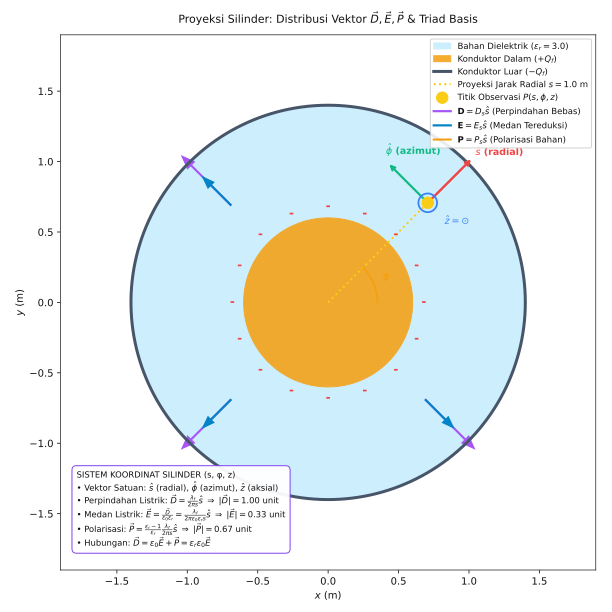

In [18]:
# Diagram Proyeksi Vektor 2D: Distribusi Vektor D, E, dan Muatan Terikat (Koordinat Silinder)
fig, ax = plt.subplots(dpi=120)

a_val, b_val = 0.6, 1.4
eps_r = 3.0
th_c = np.linspace(0, 2*np.pi, 200)

ax.fill(b_val*np.cos(th_c), b_val*np.sin(th_c), color='#38bdf8', alpha=0.25, label=f'Bahan Dielektrik ($\\epsilon_r = {eps_r}$)')
ax.fill(a_val*np.cos(th_c), a_val*np.sin(th_c), color='#f59e0b', alpha=0.85, label=r'Konduktor Dalam ($+Q_f$)')
ax.plot(b_val*np.cos(th_c), b_val*np.sin(th_c), color='#475569', lw=3.0, label=r'Konduktor Luar ($-Q_f$)')

# Titik observasi P(s0, phi0)
s0 = 1.0
phi0 = np.pi / 4.0
xp = s0 * np.cos(phi0)
yp = s0 * np.sin(phi0)

ax.plot([0, xp], [0, yp], color='#facc15', ls=':', lw=2, label=r'Proyeksi Jarak Radial $s = 1.0\text{ m}$')
arc_phi = np.linspace(0, phi0, 30)
ax.plot(0.35*np.cos(arc_phi), 0.35*np.sin(arc_phi), color='#f59e0b', lw=1.6)
ax.text(0.42*np.cos(phi0/2), 0.42*np.sin(phi0/2), r'$\phi$', color='#f59e0b', fontsize=10, fontweight='bold')

ax.scatter([xp], [yp], color='#facc15', s=130, zorder=8, label=r'Titik Observasi $P(s, \phi, z)$')

# Triad Vektor Satuan Silinder di Titik P
# 1. s_hat (radial keluar)
ax.annotate('', xy=(xp + 0.45*np.cos(phi0), yp + 0.45*np.sin(phi0)), xytext=(xp, yp),
            arrowprops=dict(arrowstyle="->", color='#ef4444', lw=2.4))
ax.text(xp + 0.48*np.cos(phi0), yp + 0.48*np.sin(phi0), r'$\hat{s}$ (radial)', color='#ef4444', fontweight='bold', fontsize=9.5)

# 2. phi_hat (tangensial berlawanan arah jarum jam)
ax.annotate('', xy=(xp - 0.4*np.sin(phi0), yp + 0.4*np.cos(phi0)), xytext=(xp, yp),
            arrowprops=dict(arrowstyle="->", color='#10b981', lw=2.2))
ax.text(xp - 0.42*np.sin(phi0), yp + 0.42*np.cos(phi0) + 0.05, r'$\hat{\phi}$ (azimut)', color='#10b981', fontweight='bold', fontsize=9.5)

# 3. z_hat (aksial menembus bidang keluar)
ax.scatter([xp], [yp], facecolors='none', edgecolors='#3b82f6', s=350, lw=1.8, zorder=9)
ax.text(xp + 0.12, yp - 0.15, r'$\hat{z} = \odot$', color='#3b82f6', fontweight='bold', fontsize=9.5)

# Vektor D, E, dan P pada kuadran lain
for th in [np.pi*0.75, np.pi*1.25, np.pi*1.75]:
    sm = 0.98
    ax.arrow(sm*np.cos(th), sm*np.sin(th), 0.4*np.cos(th), 0.4*np.sin(th),
             head_width=0.06, head_length=0.08, fc='#a855f7', ec='#a855f7', lw=2.0)
    ax.arrow(sm*np.cos(th), sm*np.sin(th), 0.2*np.cos(th), 0.2*np.sin(th),
             head_width=0.05, head_length=0.07, fc='#0284c7', ec='#0284c7', lw=2.0)

ax.plot([], [], color='#a855f7', lw=2.2, label=r'$\mathbf{D} = D_s\hat{s}$ (Perpindahan Bebas)')
ax.plot([], [], color='#0284c7', lw=2.2, label=r'$\mathbf{E} = E_s\hat{s}$ (Medan Tereduksi)')
ax.plot([], [], color='#f59e0b', lw=2.0, label=r'$\mathbf{P} = P_s\hat{s}$ (Polarisasi Bahan)')

# Muatan terikat di antarmuka s = a
for th in np.linspace(0, 2*np.pi, 16, endpoint=False):
    ax.text((a_val + 0.08)*np.cos(th), (a_val + 0.08)*np.sin(th), '-',
            color='#ef4444', fontsize=12, fontweight='bold', ha='center', va='center')

# Info card: Sistem Koordinat Silinder, Besar Vektor D, E, P, dan Hubungan Konstitutif
info_diel = (
    "SISTEM KOORDINAT SILINDER (s, φ, z)\n"
    r"• Vektor Satuan: $\hat{s}$ (radial), $\hat{\phi}$ (azimut), $\hat{z}$ (aksial)" + "\n"
    r"• Perpindahan Listrik: $\vec{D} = \frac{\lambda_f}{2\pi s}\hat{s}\ \Rightarrow\ |\vec{D}| = 1.00\ \mathrm{unit}$" + "\n"
    r"• Medan Listrik: $\vec{E} = \frac{\vec{D}}{\epsilon_0\epsilon_r} = \frac{\lambda_f}{2\pi\epsilon_0\epsilon_r s}\hat{s}\ \Rightarrow\ |\vec{E}| = 0.33\ \mathrm{unit}$" + "\n"
    r"• Polarisasi: $\vec{P} = \frac{\epsilon_r - 1}{\epsilon_r}\frac{\lambda_f}{2\pi s}\hat{s}\ \Rightarrow\ |\vec{P}| = 0.67\ \mathrm{unit}$" + "\n"
    r"• Hubungan: $\vec{D} = \epsilon_0\vec{E} + \vec{P} = \epsilon_r\epsilon_0\vec{E}$"
)
ax.text(0.03, 0.04, info_diel, transform=ax.transAxes, fontsize=8.4,
        bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#7c3aed', alpha=0.94),
        va='bottom', ha='left')

ax.set_aspect('equal')
ax.set_title(r'Proyeksi Silinder: Distribusi Vektor $\vec{D}, \vec{E}, \vec{P}$ & Triad Basis',
             fontsize=11, color='#111111', pad=12)
ax.set_xlabel('$x$ (m)', fontsize=10)
ax.set_ylabel('$y$ (m)', fontsize=10)
ax.set_xlim(-1.9, 1.9)
ax.set_ylim(-1.9, 1.9)
ax.legend(loc='upper right', framealpha=0.88, facecolor='white', edgecolor='#cccccc', fontsize=8.5)

plt.tight_layout()
plt.show()


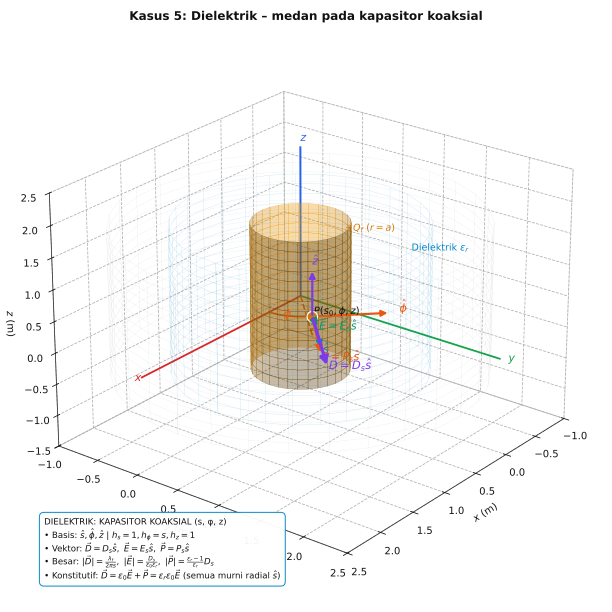

In [19]:
# Visualisasi 3D: Kasus 5: Dielektrik – medan pada kapasitor koaksial
def plot_coaxial_scene(title="Proyeksi Koordinat Silinder: Vektor D, E, dan P pada Dielektrik Koaksial 3D"):
    """Visualisasi Proyeksi 3D Vektor D, E, dan P pada Kapasitor Koaksial Berdielektrik."""
    fig = plt.figure(dpi=120)
    ax = fig.add_subplot(111, projection='3d')
    setup_3d_pane(ax, xlim=(-1.0, 2.5), ylim=(-1.0, 2.5), zlim=(-1.5, 2.5), axis_len=2.4)
    
    a_rad = 0.5
    b_rad = 1.3
    c_rad = 1.9
    L = 2.4
    
    # Wireframe silinder koaksial
    zc = np.linspace(-L/2, L/2, 16)
    phic = np.linspace(0, 2*np.pi, 32)
    PHIC, ZC = np.meshgrid(phic, zc)
    
    # 1. Konduktor dalam (r = a)
    Xa = a_rad * np.cos(PHIC); Ya = a_rad * np.sin(PHIC)
    ax.plot_surface(Xa, Ya, ZC, color='#f59e0b', alpha=0.35, edgecolors='#f59e0b', lw=0.2)
    ax.text(0, a_rad+0.05, L/2+0.08, r'$+Q_f\ (r=a)$', color='#d97706', fontweight='bold', fontsize=9.5)
    
    # 2. Bahan dielektrik (r = b)
    Xb = b_rad * np.cos(PHIC); Yb = b_rad * np.sin(PHIC)
    ax.plot_wireframe(Xb, Yb, ZC, color='#0284c7', lw=0.35, alpha=0.22)
    ax.text(0, b_rad+0.05, L/2+0.08, r'$\text{Dielektrik } \epsilon_r$', color='#0284c7', fontweight='bold', fontsize=9.5)
    
    # 3. Konduktor luar (r = c)
    Xc = c_rad * np.cos(PHIC); Yc = c_rad * np.sin(PHIC)
    ax.plot_wireframe(Xc, Yc, ZC, color='#64748b', lw=0.25, alpha=0.18)
    
    # Titik observasi P(s, phi, z) di dalam dielektrik (a < s < b)
    s0 = 0.95
    phi0 = np.pi / 4.0
    z0 = 0.3
    xp = s0 * np.cos(phi0)
    yp = s0 * np.sin(phi0)
    zp = z0
    
    ax.scatter([xp], [yp], [zp], color='#d97706', s=110, zorder=15, edgecolors='white', lw=1.2)
    ax.text(xp+0.08, yp+0.08, zp+0.12, r'$P(s_0, \phi, z)$', color='#111111', fontweight='bold', fontsize=10)
    
    # Proyeksi silinder: garis drop ke xy, garis radial di xy, busur phi
    ax.plot([xp, xp], [yp, yp], [0, zp], color='#d97706', ls=':', lw=2.0)
    ax.plot([0, xp], [0, yp], [0, 0], color='#ea580c', ls='--', lw=1.6)
    arc_phi = np.linspace(0, phi0, 25)
    ax.plot(0.5*np.cos(arc_phi), 0.5*np.sin(arc_phi), 0, color='#ea580c', lw=1.8)
    ax.text(0.6*np.cos(phi0/2), 0.6*np.sin(phi0/2), 0.04, r'$\phi$', color='#ea580c', fontweight='bold', fontsize=11)
    
    # Triad Basis Silinder di P
    u_len = 0.75
    s_hat = np.array([np.cos(phi0), np.sin(phi0), 0.0])
    phi_hat = np.array([-np.sin(phi0), np.cos(phi0), 0.0])
    z_hat = np.array([0.0, 0.0, 1.0])
    
    ax.add_artist(Arrow3D([xp, xp+u_len*s_hat[0]], [yp, yp+u_len*s_hat[1]], [zp, zp+u_len*s_hat[2]],
                          mutation_scale=12, color='#0284c7', arrowstyle='-|>', lw=2.2))
    ax.text(xp+u_len*s_hat[0]+0.06, yp+u_len*s_hat[1]+0.06, zp, r'$\hat{s}$', color='#0284c7', fontweight='bold', fontsize=11)
    
    ax.add_artist(Arrow3D([xp, xp+u_len*phi_hat[0]], [yp, yp+u_len*phi_hat[1]], [zp, zp+u_len*phi_hat[2]],
                          mutation_scale=12, color='#ea580c', arrowstyle='-|>', lw=2.2))
    ax.text(xp+u_len*phi_hat[0]-0.08, yp+u_len*phi_hat[1]+0.06, zp, r'$\hat{\phi}$', color='#ea580c', fontweight='bold', fontsize=11)
    
    ax.add_artist(Arrow3D([xp, xp], [yp, yp], [zp, zp+u_len],
                          mutation_scale=12, color='#7c3aed', arrowstyle='-|>', lw=2.2))
    ax.text(xp, yp, zp+u_len+0.08, r'$\hat{z}$', color='#7c3aed', fontweight='bold', fontsize=11)
    
    # Vektor D, E, dan P di titik observasi
    # D (perpindahan bebas): panjang 1.15, warna ungu
    D_len = 1.15
    ax.add_artist(Arrow3D([xp, xp+D_len*s_hat[0]], [yp, yp+D_len*s_hat[1]], [zp, zp],
                          mutation_scale=16, color='#7c3aed', arrowstyle='-|>', lw=3.2))
    ax.text(xp+D_len*s_hat[0]+0.08, yp+D_len*s_hat[1]+0.08, zp+0.05,
            r'$\vec{D} = D_s\hat{s}$', color='#7c3aed', fontweight='bold', fontsize=11.5)
    
    # P (polarisasi): panjang 0.70, warna oranye
    P_len = 0.70
    ax.add_artist(Arrow3D([xp, xp+P_len*s_hat[0]], [yp, yp+P_len*s_hat[1]], [zp, zp-0.12],
                          mutation_scale=13, color='#ea580c', arrowstyle='-|>', lw=2.6))
    ax.text(xp+P_len*s_hat[0]+0.06, yp+P_len*s_hat[1]+0.06, zp-0.15,
            r'$\vec{P} = P_s\hat{s}$', color='#ea580c', fontweight='bold', fontsize=11)
    
    # E (medan tereduksi): panjang 0.45, warna emerald
    E_len = 0.45
    ax.add_artist(Arrow3D([xp, xp+E_len*s_hat[0]], [yp, yp+E_len*s_hat[1]], [zp, zp+0.12],
                          mutation_scale=13, color='#059669', arrowstyle='-|>', lw=2.8))
    ax.text(xp+E_len*s_hat[0]+0.06, yp+E_len*s_hat[1]+0.06, zp+0.16,
            r'$\vec{E} = E_s\hat{s}$', color='#059669', fontweight='bold', fontsize=11)
    
    card_coax = (
        "DIELEKTRIK: KAPASITOR KOAKSIAL (s, φ, z)\n"
        r"• Basis: $\hat{s}, \hat{\phi}, \hat{z}$ | $h_s=1, h_\phi=s, h_z=1$" + "\n"
        r"• Vektor: $\vec{D} = D_s\hat{s},\ \vec{E} = E_s\hat{s},\ \vec{P} = P_s\hat{s}$" + "\n"
        r"• Besar: $|\vec{D}| = \frac{\lambda_f}{2\pi s},\ |\vec{E}| = \frac{D_s}{\epsilon_0\epsilon_r},\ |\vec{P}| = \frac{\epsilon_r-1}{\epsilon_r}D_s$" + "\n"
        r"• Konstitutif: $\vec{D} = \epsilon_0\vec{E} + \vec{P} = \epsilon_r\epsilon_0\vec{E}$ (semua murni radial $\hat{s}$)"
    )
    ax.text2D(0.04, 0.04, card_coax, transform=ax.transAxes, fontsize=8.6,
              bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#0284c7', alpha=0.95),
              color='#111111')
    
    ax.set_title(title, color='#111111', fontsize=12, pad=12, fontweight='bold')
    ax.view_init(elev=24, azim=38)
    plt.tight_layout()
    plt.show()
    plt.close()

plot_coaxial_scene("Kasus 5: Dielektrik – medan pada kapasitor koaksial")


---
## 7. Rangkuman Komparatif & Kesimpulan Akhir

| No | Topik / Kasus Analitik | Prinsip & Hukum Pokok | Karakteristik Medan $\mathbf{E}$ | Potensial Skalar $V(\mathbf{r})$ | Manifestasi Persamaan Superposisi |
| :---: | :--- | :--- | :--- | :--- | :--- |
| **1** | **Gaya Listrik & Hukum Coulomb** | Superposisi linier & integrasi $dq'$ | $E_s = \frac{\lambda L}{4\pi\epsilon_0 s \sqrt{s^2 + L^2/4}}$, $E_z = 0$ | $V(s) = \frac{\lambda}{2\pi\epsilon_0}\ln(s_0/s)$ $(L \to \infty)$ | $\mathbf{E} = \int d\mathbf{E}$. Superposisi pasangan elemen simetris $\pm z'$: $dE_z$ saling meniadakan, $dE_s$ saling menguatkan. |
| **2** | **Medan Listrik & Hukum Gauss** | Fluks permukaan tertutup $\oint \mathbf{E}\cdot d\mathbf{a} = \frac{Q_{\text{enc}}}{\epsilon_0}$ | Di dalam: $E \propto r$ (linear)<br>Di luar: $E \propto 1/r^2$ (Newtonian) | $V_{\text{in}}(r) = \frac{Q}{8\pi\epsilon_0 R}(3 - r^2/R^2)$<br>$V_{\text{out}}(r) = \frac{Q}{4\pi\epsilon_0 r}$ | Superposisi kulit bola $\mathbf{E} = \int d\mathbf{E}_{\text{kulit}}$. Superposisi rongga eksentrik: $\mathbf{E}_{\text{rongga}} = \frac{\rho_0}{3\epsilon_0}\mathbf{d}$ (homogen). |
| **3** | **Potensial & Persamaan Laplace** | $\mathbf{E} = -\nabla V$, $\nabla^2 V = 0$ (ruang bebas) | Ortogonal terhadap permukaan ekipotensial | Memenuhi teorema nilai rata-rata, tidak ada ekstrem lokal di vakum | $V = \sum V_i$ (superposisi skalar linear). Energi bersifat non-linear: $W = W_1 + W_2 + \epsilon_0\int \mathbf{E}_1\cdot\mathbf{E}_2 d\tau$. |
| **4** | **Syarat Batas & Separasi Variabel** | Teorema Keunikan Dirichlet & Neumann, Laplace $\nabla^2 V = 0$ | $\mathbf{E}$ menumbuk tegak lurus konduktor ($E_\parallel = 0$) | Solusi deret Fourier eksak: $V(x,y) = \frac{4V_0}{\pi}\sum_{n=1,3,5,\ldots}\frac{1}{n}\sin(k_n x)\frac{\sinh(k_n y)}{\sinh(k_n b)}$ | Superposisi tak hingga deret moda ortogonal $\sum C_n X_n Y_n$. Teorema keunikan menjamin solusi superposisi ini tunggal untuk persamaan sumber dan kondisi batas yang ditetapkan. |
| **5** | **Bahan Dielektrik & Kapasitansi** | Polarisasi $\mathbf{P}$, Vektor $\mathbf{D} = \epsilon_r\epsilon_0\mathbf{E}$ | Pada kapasitor bermuatan bebas tetap, $|\mathbf{E}|=|\mathbf{E}_0|/\epsilon_r$; $\mathbf{D}$ ditentukan oleh muatan bebas | $\Delta V = \frac{\lambda_f}{2\pi\epsilon_r\epsilon_0}\ln(b/a)$ | $\mathbf{E} = \mathbf{E}_0 + \mathbf{E}_{\text{pol}}$. Superposisi beda potensial seri: $\Delta V = \sum \Delta V_k \implies 1/C_{\text{total}} = \sum 1/C_k$. |

### Kesimpulan Fisis & Relevansi Elektrodinamika Lanjut
1. **Unifikasi Elektrostatika & Universalitas Superposisi:** Seluruh fenomena elektrostatik berakar pada linearitas persamaan Maxwell statik. Persamaan superposisi menjembatani hukum-hukum fundamental: dari interaksi gaya mikroskopis Coulomb menuju medan terdistribusi Gauss, masalah nilai batas konduktor, hingga respon polarisasi materi dielektrik.
2. **Kekuatan Teorema Keunikan:** Persamaan Laplace atau Poisson bersama data batas yang lengkap menentukan solusi potensial secara unik (dengan kebebasan konstanta untuk syarat Neumann murni).
3. **Jembatan Menuju Elektrodinamika Relativistik:** Dalam kerangka teori relativitas khusus Einstein, medan elektrostatik $\mathbf{E}$ dan medan magnetostatik $\mathbf{B}$ menyatu ke dalam **Tensor Kuat Medan Elektromagnetik 4-Dimensi** $F^{\mu\nu}$:
   $$F^{\mu\nu} = \partial^\mu A^\nu - \partial^\nu A^\mu = \begin{pmatrix} 0 & -E_x/c & -E_y/c & -E_z/c \\ E_x/c & 0 & -B_z & B_y \\ E_y/c & B_z & 0 & -B_x \\ E_z/c & -B_y & B_x & 0 \end{pmatrix}$$
   di mana potensial elektrostatik $V$ berkombinasi dengan potensial vektor magnetik $\mathbf{A}$ membentuk **Empat-Potensial Relativistik** $A^\mu = (V/c, \mathbf{A})$. Transformasi Lorentz memperlihatkan bahwa medan listrik murni dalam suatu kerangka acuan diam akan termanifestasi sebagai kombinasi medan listrik dan medan magnet bagi pengamat yang bergerak.
